# Therapy prediction plots: 3D plots of $a$, $f$, and $c$

This file generates Figure 6 in the main text, and Supplementary Figures S3, S4, S5, and S6.

It requires that the parameter estimation has been completed and there exists a file with those results (the results of running runner_t_3d.py). It also requires the optimal parameter estimation for each mouse (the results of running analyse_t.ipynb with $n=1$). To regenerate the figures in the text, use the data in Supplementary Data File X. Edit the location of those files below. It loads the point cloud from that file and turns the shapes of the proliferative subclone, invasive subclone, and tumor elimination area (as appropriate) into 3D ($c$, $a$, $f$)-space meshes using PyVista. These meshes are plotted in 3D space and saved if desired.

## Load needed packages

In [1]:
%matplotlib widget
import matplotlib as mpl
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import os
import pyvista as pv
from shapely.geometry import Polygon
from shapely import intersection_all
import shapely as sh
pv.global_theme.allow_empty_mesh = True
pv.set_jupyter_backend("static")

## Define data and user input-parameters

In [2]:
result_dir = "results_path/"
bests_file = "bests/t_1.csv"

figure_save_path = "figures/3d/" # Set to None to not save the figures

volume_save_path = "volumes/" # Set to None not to save the volumes

groups = ["Grp. A1 B6 (100% C1)", "Grp. A2 B6 (80% C1; 20% C11)", "Grp. A3 B6 (50% C1; 50% C11)", "Grp. A4 B6 (20% C1; 80% C11)", "Grp. A5 B6 (100% C11)"]

## Read in data

In [3]:
results = []
for fname in os.listdir(result_dir):
    results += [pd.read_csv(result_dir + fname)]
results = pd.concat(results)
results.loc[results["group"]=="1C", "group"] = "Grp. A1 B6 (100% C1)"
results.loc[results["group"]=="2C", "group"] = "Grp. A2 B6 (80% C1; 20% C11)"
results.loc[results["group"]=="3C", "group"] = "Grp. A3 B6 (50% C1; 50% C11)"
results.loc[results["group"]=="4C", "group"] = "Grp. A4 B6 (20% C1; 80% C11)"
results.loc[results["group"]=="5C", "group"] = "Grp. A5 B6 (100% C11)"
results

,group,id,g1,g11,m,k,c,a,f,b,l,error,winner
0,Grp. A2 B6 (80% C1; 20% C11),431,0.166,0.141,-0.095,0.085,0.1,0.0,0.0,0.05,0.01,1.906967e+10,0.0
1,Grp. A2 B6 (80% C1; 20% C11),432,0.166,0.141,-0.095,0.085,0.1,0.0,0.0,0.05,0.01,3.649682e+13,0.0
2,Grp. A2 B6 (80% C1; 20% C11),433,0.166,0.141,-0.095,0.085,0.1,0.0,0.0,0.05,0.01,1.152644e+13,0.0
3,Grp. A2 B6 (80% C1; 20% C11),435,0.166,0.141,-0.095,0.085,0.1,0.0,0.0,0.05,0.01,1.991504e+07,0.0
4,Grp. A2 B6 (80% C1; 20% C11),431,0.166,0.141,-0.095,0.085,0.1,0.0,0.2,0.05,0.01,1.906967e+10,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20686,Grp. A2 B6 (80% C1; 20% C11),435,0.166,0.141,-0.045,0.045,1.0,2.0,1.8,0.04,0.01,inf,1.0
20687,Grp. A2 B6 (80% C1; 20% C11),431,0.166,0.141,-0.045,0.045,1.0,2.0,2.0,0.04,0.01,inf,1.0
20688,Grp. A2 B6 (80% C1; 20% C11),432,0.166,0.141,-0.045,0.045,1.0,2.0,2.0,0.04,0.01,inf,1.0
20689,Grp. A2 B6 (80% C1; 20% C11),433,0.166,0.141,-0.045,0.045,1.0,2.0,2.0,0.04,0.01,inf,1.0


In [4]:
# Read in the best values
bests = pd.read_csv(bests_file)
bests = bests.sort_values(["group", "id"]).reset_index(drop=True)
# Merge with the results data frame and subset to those with the optimal values
best_results = pd.merge(bests, results, how="left", on=["group", "id", "g1", "g11", "m", "k", "b", "l"], suffixes=["", "_y"])
best_results = best_results.drop(["c_y", "a_y", "f_y", "error_y", "winner_y"], axis=1)
best_results = best_results.drop_duplicates().reset_index()
best_results = best_results.drop(["level_0", "Unnamed: 0", "index"], axis=1)
best_results

,group,id,g1,g11,m,k,c,a,f,b,l,error,winner,log_error
0,Grp. A1 B6 (100% C1),424,0.166,0.141,-0.055,0.495,0.04,1.9,1.7,0.03,0.01,2.818525e+02,0.0,5.641384
1,Grp. A1 B6 (100% C1),425,0.166,0.142,-0.060,0.060,0.42,0.5,1.9,0.01,0.01,5.707592e+02,0.0,6.346967
2,Grp. A1 B6 (100% C1),427,0.166,0.127,-0.150,0.315,0.32,0.2,1.2,0.01,0.01,6.252578e+02,0.0,6.438164
3,Grp. A1 B6 (100% C1),600,0.166,0.142,-0.140,0.265,0.08,1.0,1.2,0.01,0.01,5.897549e+02,0.0,6.379707
4,Grp. A1 B6 (100% C1),601,0.166,0.142,-0.190,0.450,0.36,0.2,1.3,0.02,0.01,2.046727e+03,0.0,7.623997
5,Grp. A1 B6 (100% C1),602,0.171,0.141,-0.160,0.435,0.50,0.3,0.1,0.10,0.01,2.897730e+03,0.0,7.971683
6,Grp. A1 B6 (100% C1),609,0.171,0.141,-0.140,0.385,0.04,0.7,0.6,0.01,0.01,1.197924e+03,0.0,7.088345
7,Grp. A2 B6 (80% C1; 20% C11),431,0.166,0.141,-0.595,0.760,0.26,1.2,1.5,0.04,0.01,4.452944e+02,0.0,6.098736
8,Grp. A2 B6 (80% C1; 20% C11),432,0.166,0.141,-0.095,0.085,0.28,1.2,1.5,0.05,0.01,9.235458e+02,0.0,6.828220
9,Grp. A2 B6 (80% C1; 20% C11),433,0.166,0.142,-0.055,0.050,0.54,0.5,0.5,0.07,0.01,1.219007e+03,0.0,7.105791


## Functions

Function to find the next clockwise point.

@param p : current point [<i>x</i>, <i>y</i>]

@param b : last point [<i>x</i>, <i>y</i>]

@param max_x : the maximum possible <i>x</i> value

@param max_y : the maximum possible <i>y</i> value

In [5]:
def next_clockwise(p, b, max_x, max_y, i):
    # Out is next clockwise point
    out = None
    
    # Compare current point to previous point to find the next clockwise point
    if b[0] < p[0]: # we're currently to the left
        if b[1] < p[1]: # we're currently above
            out = [b[0]+1, b[1]] # move right
        else: # we're currently equal y or below
            out = [b[0], b[1]-1] # move up
    elif b[0] == p[0]: # we're currently same x
        if b[1] < p[1]: # we're currently above
            out = [b[0]+1, b[1]] # move right
        else: # we're currently below
            out = [b[0]-1, b[1]] # move left
    else: # b[0] > p[0], we're currently to the right
        if b[1] <= p[1]: # we're currently above or equal y
            out = [b[0], b[1]+1] # move down
        else: # we're currently below
            out = [b[0]-1, b[1]] # move left
    
    # If the next clockwise point is out of bounds, call function again setting the previous point to out of bounds next point
    if out[0] < 0 or out[1] < 0: return next_clockwise(p, out, max_x, max_y, i+1)
    if out[0] > max_x or out[1] > max_y: return next_clockwise(p, out, max_x, max_y, i+1)
    
    # Return next clockwise point
    return out, i

Moore-neighbor tracing algorithm: 
https://en.wikipedia.org/wiki/Moore_neighborhood#Algorithm

@param df : 2D dataframe with 0s where C1 (proliferative) wins, 1 where C11 (invasive) wins, and 2s where both subclones are eliminated

@param v : Binary flag for which subclone we want to trace. 0 for C1 (proliferative), 1 for C11 (invasive)

@return : Returns a list of points that outline the shape defined by the points in the dataframe associated with the given subclone

In [6]:
def mnt(df, v, exclude=[]):
    # trace will keep track of the points we've visited in order
    trace = []
    
    # Find a starting point for the given subclone, looping through the grid from left to right, top to bottom
    start_loc = None
    for y in range(len(df.index)):
        for x in range(len(df.columns)):
            if (df.iloc[y,x] == v) and ([x,y] not in exclude):
                start_loc = [x,y]
                break
        # Exit the loop if we've found a starting value
        if start_loc != None: break
    # If there are no values of the given color, exit
    if start_loc == None: return trace
    # print("Start loc:", start_loc, df.columns[start_loc[0]], df.index[start_loc[1]])
    # Append our starting location to our trace
    trace.append([df.columns[start_loc[0]], df.index[start_loc[1]]])
    
    # Set maximum sizes as the sizes of the grid
    max_x = len(df.columns)-1
    max_y = len(df.index)-1

    # p is our current location, set to starting point
    p = start_loc
    # b is our previous point, set it one to the left
    b = [start_loc[0]-1, start_loc[1]]
    # c is the next clockwise point around p starting from b
    c, i = next_clockwise(p, b, max_x, max_y, 0)
    
    # curr_start = c
    # print("curr_start", c, df.columns[c[0]], df.index[c[1]])
    
    # Loop until we are back to the starting point
    while c[0] != start_loc[0] or c[1] != start_loc[1]:
        # If our next clockwise point is the correct color:
        if (df.iloc[c[1], c[0]] == v) and (c not in exclude):
            trace.append([df.columns[c[0]], df.index[c[1]]]) # Add it to the trace
            b = p # Last point is now first point
            p = c # Current point is now next point
            i = 0 # reset counter
            c, i = next_clockwise(p, b, max_x, max_y, i) # Find next point
        # If the next clockwise point is not the correct color
        else:
            b = c # Our last point is the last clockwise point
            c, ix = next_clockwise(p, b, max_x, max_y, i) # Find next clockwise point
            i = i+1
        # If we've gone through all points, exclude this point and try again.
        if i >= 8:
            e = exclude + [p]
            return mnt(df, v, e)
            
    
    # Add the first point to the end of the trace
    trace.append(trace[0])
    # Return the trace
    return trace

Function to use PyVista to plot 3D shapes.

@param ds : List of <i>d</i> values of the <i>z</i> slices to plot

@param dfs : List of 2D data frames, each representing the slice of the 3D space associated with each d value

@param curr_group : The mouse group we're plotting (for save file)

@param curr_m : The <i>m</i> value for the current 3D data frame (for save file)

@param stretch : The amount to shift the <i>a</i> and <i>f</i> values of the blocks in order to more clearly see the boundaries of the shapes

In [7]:
def get_traces(cs, fake_cs, dfs, color, stretch):
    traces = []
    for idx in range(len(dfs)):
        traces += [mnt(dfs[idx], color)]
    # Update a and f values with stretch and switch the c values to the scaled c values
    traces2 = []
    for i in range(len(cs)):
        t = []
        for af in traces[i]:
            t += [[af[0]+stretch, af[1]-stretch, fake_cs[i]]]
        traces2 += t
    return traces2

Plotting function.

@param cs : The $c$ values to use

@param dfs : The 2d data frames of $a$ vs $f$ for each $c$ values

@curr_group : The index group of the mouse we are plotting (for save file)

@curr_id : The id of the mouse to plot

@stretch : The amount to stretch the spaces apart, default=0

In [20]:
def plot_3d(cs, dfs, curr_group, curr_id, stretch=0):
    # Create a list of c values, corresponding to each true c value, that match the range of a and f
    fake_cs = [2*c for c in cs]

    # Initiate plotter
    pl = pv.Plotter(notebook=True)

    # C1 (proliferative)
    traces2 = get_traces(cs, fake_cs, dfs, 0, stretch)
    if len(traces2) > 0:
        # Use PyVista to plot the 3D shape
        cloud = pv.PolyData(traces2)
        volume = cloud.delaunay_3d(alpha=0)
        shell = volume.extract_surface(algorithm=None)
        if shell.n_points > 0:
            pl.add_mesh(shell, color="#ffa500", opacity=0.5)

    # C11 (invasive)
    traces2 = get_traces(cs, fake_cs, dfs, 1, stretch)
    if len(traces2) > 0:
        # Use PyVista to plot the 3D shape
        cloud = pv.PolyData(traces2)
        volume = cloud.delaunay_3d(alpha=0)
        shell = volume.extract_surface(algorithm=None)
        if shell.n_points > 0:
            pl.add_mesh(shell, color="#0000ff", opacity=0.5)
            
    # Tumor elimination
    traces2 = get_traces(cs, fake_cs, dfs, 2, 0)
    if len(traces2) > 0:
        # Use PyVista to plot the 3D shape
        cloud = pv.PolyData(traces2)
        volume = cloud.delaunay_3d(alpha=0)
        shell = volume.extract_surface(algorithm=None)
        # print(shell.n_points)
        if shell.n_points > 0:
            pl.add_mesh(shell, color="green", opacity=0.5)
            
    # Set bounds and grid
    pl.show_bounds(location="outer", grid="front")
    # Set the camera settings
    pl.camera_position = 'yz'
    pl.camera.elevation= 30 #30
    pl.camera.azimuth = 35 # 52
    # Label the axis
    labels = dict(xtitle="f", ytitle="a", ztitle="c")
    pl.show_grid(**labels, font_size=20, font_family="arial", bold=False)#, n_xlabels=8, n_ylabels=8, n_zlabels=10)

    pl.add_title("{} {}\ng1={}, g11={} m={}, k={}".format(groups[curr_group][5:7], curr_id, curr_g1, curr_g11, curr_m, curr_k), font_size=10)
    
    # Save figure
    if figure_save_path:
        pl.save_graphic("{}{}_{}.svg".format(figure_save_path, groups[curr_group][5:7], curr_id))

    # Show figure
    pl.show()

Function to get 2d data frames of $a$ vs $f$ for each $c$ value.

@param idx : The index of the mouse to evaluate

In [9]:
def get_dfs(idx):
    curr_group = groups.index(best_results.loc[idx, "group"])
    curr_id = best_results.loc[idx, "id"]
    curr_g1 = best_results.loc[idx, "g1"]
    curr_g11 = best_results.loc[idx, "g11"]
    curr_m = best_results.loc[idx, "m"]
    curr_k = best_results.loc[idx, "k"]
    curr_b = best_results.loc[idx, "b"]
    
    temp = results[(results["group"] == groups[curr_group]) & (results["g1"] == curr_g1) & (results["g11"] == curr_g11) 
                        & (results["m"] == curr_m) & (results["k"] == curr_k) & (results["b"] == curr_b)]
    temp = temp[["c", "a", "f", "winner"]]
    temp = temp.drop_duplicates()
    temp = temp.groupby(["c", "a", "f"]).max().reset_index() # This just drops the separation between mice -- all mice will be the same, so this could be max, min, whatever
    
    # Dataframes associated with d values
    dfs = [pd.pivot(temp[temp["c"] == c], index="a", columns="f", values="winner") for c in cs]

    return dfs, curr_id, curr_group, curr_g1, curr_g11, curr_m, curr_k, curr_b

Function to get the volumes of each region for all mice.

In [10]:
def get_vols():
    vols = []

    cs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    
    for idx in range(0, len(best_results)):
        curr_group = groups.index(best_results.loc[idx, "group"])
        curr_id = best_results.loc[idx, "id"]
        curr_g1 = best_results.loc[idx, "g1"]
        curr_g11 = best_results.loc[idx, "g11"]
        curr_m = best_results.loc[idx, "m"]
        curr_k = best_results.loc[idx, "k"]
        curr_b = best_results.loc[idx, "b"]
    
        temp = results[(results["group"] == groups[curr_group]) & (results["g1"] == curr_g1) & (results["g11"] == curr_g11) 
                            & (results["m"] == curr_m) & (results["k"] == curr_k) & (results["b"] == curr_b)]
        temp = temp[["c", "a", "f", "winner"]]
        temp = temp.drop_duplicates()
        temp = temp.groupby(["c", "a", "f"]).max().reset_index() # This just drops the separation between mice -- all mice will be the same, so this could be max, min, whatever
    
        # Dataframes associated with d values
        dfs = [pd.pivot(temp[temp["c"] == c], index="a", columns="f", values="winner") for c in cs]
    
        c1 = 0
        c11 = 0
        te = 0
        
        for c in range(len(cs)):
            x = mnt(dfs[c], 0)
            if len(x) > 0:
                p = Polygon(x)
                c1 += p.area*0.1
            x = mnt(dfs[c], 1)
            if len(x) > 0:
                p = Polygon(x)
                c11 += p.area*0.1
            x = mnt(dfs[c], 2)
            if len(x) > 0:
                p = Polygon(x)
                te += p.area*0.1
        vols += [[groups[curr_group], curr_id, c1, c11, te]]
    
    vols = pd.DataFrame(vols, columns=["group", "id", "c1", "c11", "te"])
    return (vols)

Function to get the volumes of the overlapping regions across groups.

@param group : the index of the group to get the overlapping volumes of. -1 means all groups except for A5 (which has only invasive winning)

In [11]:
def get_overlap_vols(group):
    cs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

    if group >=0:
        group_df = best_results[best_results["group"] == groups[group]]
    else:
        group_df = best_results[best_results["group"] != groups[-1]]

    c1_overlaps = []
    c11_overlaps = []
    te_overlaps = []
    
    for c in range(len(cs)):    
        c1 = []
        c11 = []
        te = []
        
        for idx, row in group_df.iterrows():
            dfs, curr_id, curr_group, curr_g1, curr_g11, curr_m, curr_k, curr_b = get_dfs(idx)
            if row["id"]==431: continue # Mouse 431 is an A2 mouse with no C11 winning region

            x = mnt(dfs[c], 0)
            c1 += [sh.buffer(Polygon(x), 0)]
            if curr_group != 0:
                x = mnt(dfs[c], 1)
                c11 += [sh.buffer(Polygon(x), 0)]
            x = mnt(dfs[c], 2)
            te += [sh.buffer(Polygon(x), 0)]
    
        try:
            c1_overlaps += [intersection_all(c1).area]
        except:
            c1_overlaps += [0]
        try:
            c11_overlaps += [intersection_all(c11).area]
        except:
            c11_overlaps += [0]
        try:
            te_overlaps += [intersection_all(te).area]
        except:
            te_overlaps += [0]
    return [round(sum(c1_overlaps)*0.1, 2), round(sum(c11_overlaps)*0.1, 2), round(sum(te_overlaps)*0.1, 2)]

## Plot all mice

Note that the plotted figure will have the scaled $c$ values, not the true $c$ values.

2026-05-28 09:54:48.185 ( 208.251s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x555786d670a0): 6 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:54:48.212 ( 208.278s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x555786d670a0): 1 degenerate triangles encountered, mesh quality suspect


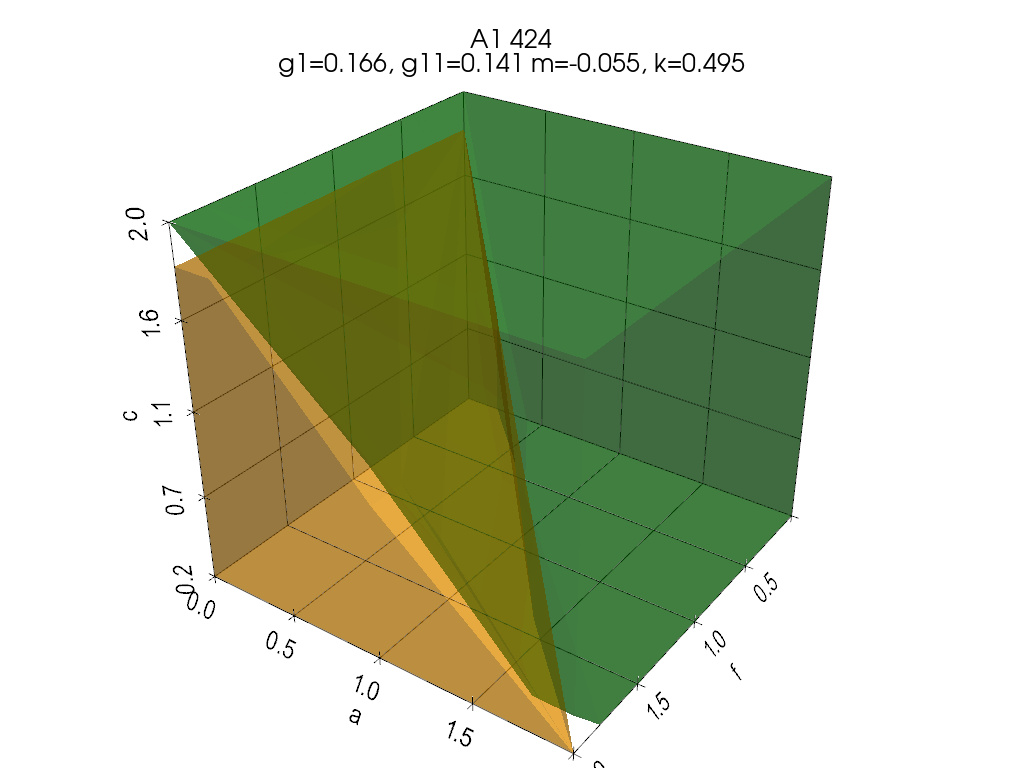

2026-05-28 09:54:48.993 ( 209.058s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557879c9670): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:54:49.020 ( 209.086s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557757fa650): 3 degenerate triangles encountered, mesh quality suspect


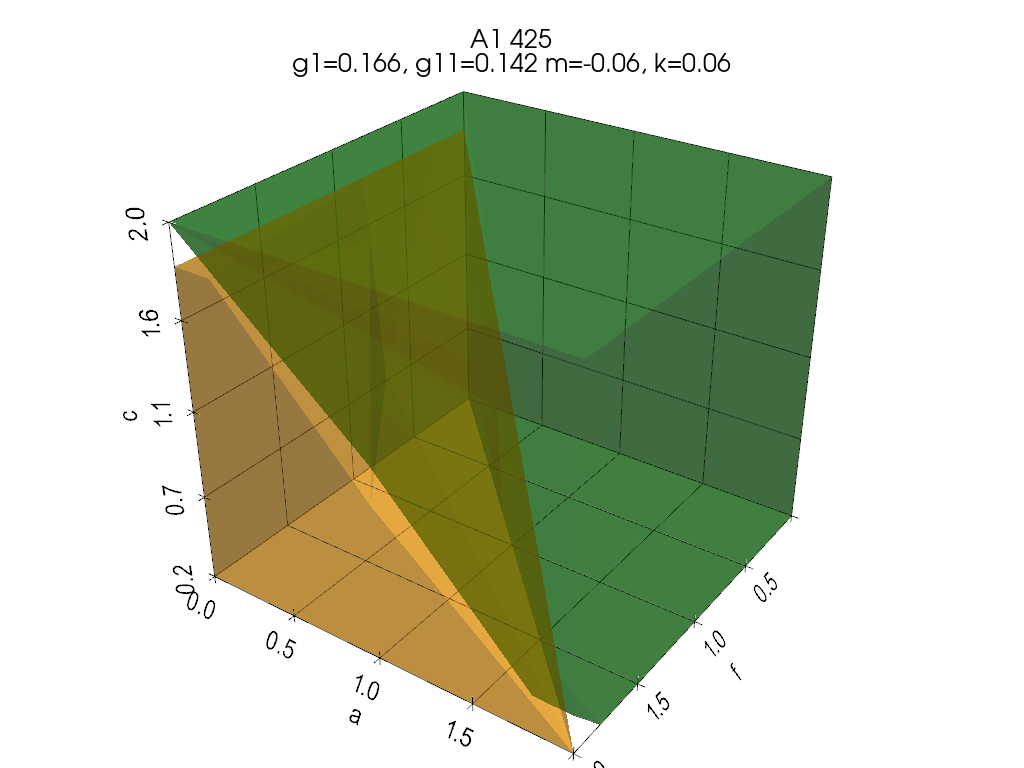

2026-05-28 09:54:49.743 ( 209.809s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x55578fab0160): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:54:49.771 ( 209.837s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x55577132ae50): 3 degenerate triangles encountered, mesh quality suspect


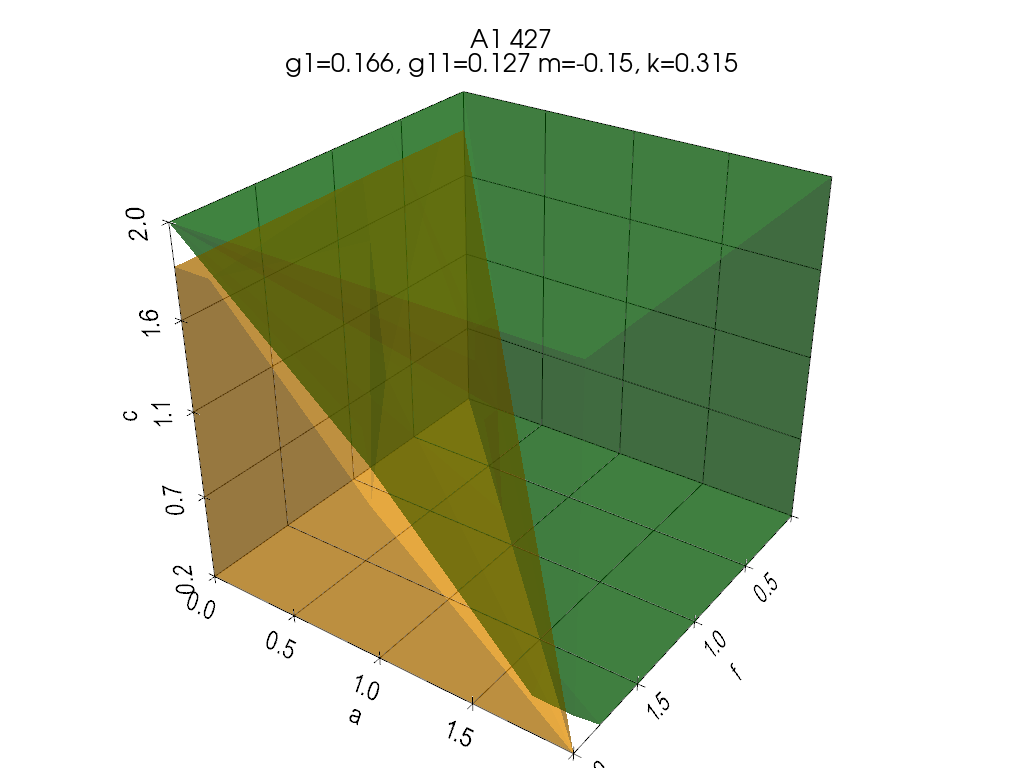

2026-05-28 09:54:50.502 ( 210.568s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x55578fa6a440): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:54:50.530 ( 210.596s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x55578fa6a440): 3 degenerate triangles encountered, mesh quality suspect


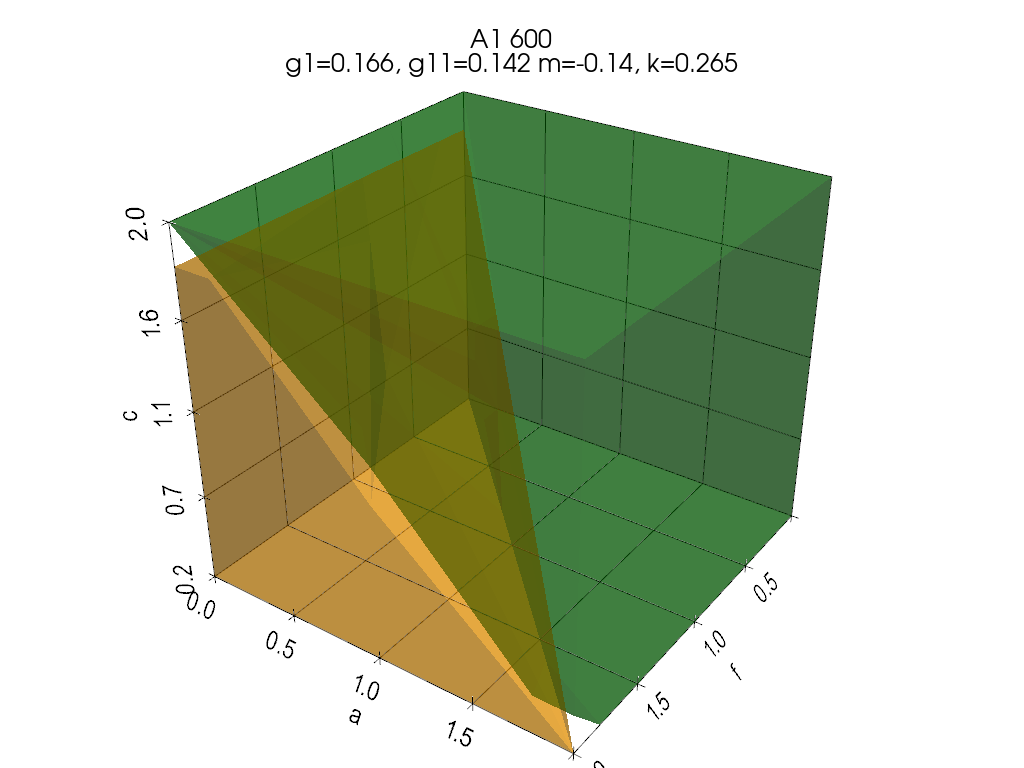

2026-05-28 09:54:51.395 ( 211.460s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x555799196d10): 3 degenerate triangles encountered, mesh quality suspect


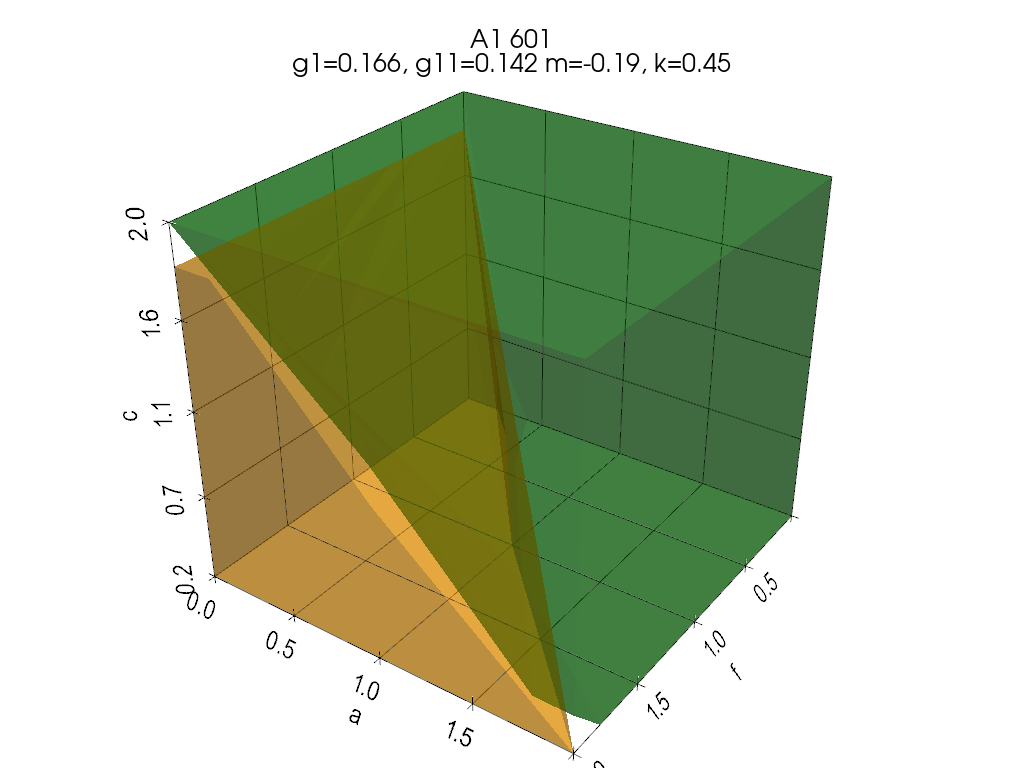

2026-05-28 09:54:52.347 ( 212.412s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x55579dd2fb50): 2 degenerate triangles encountered, mesh quality suspect


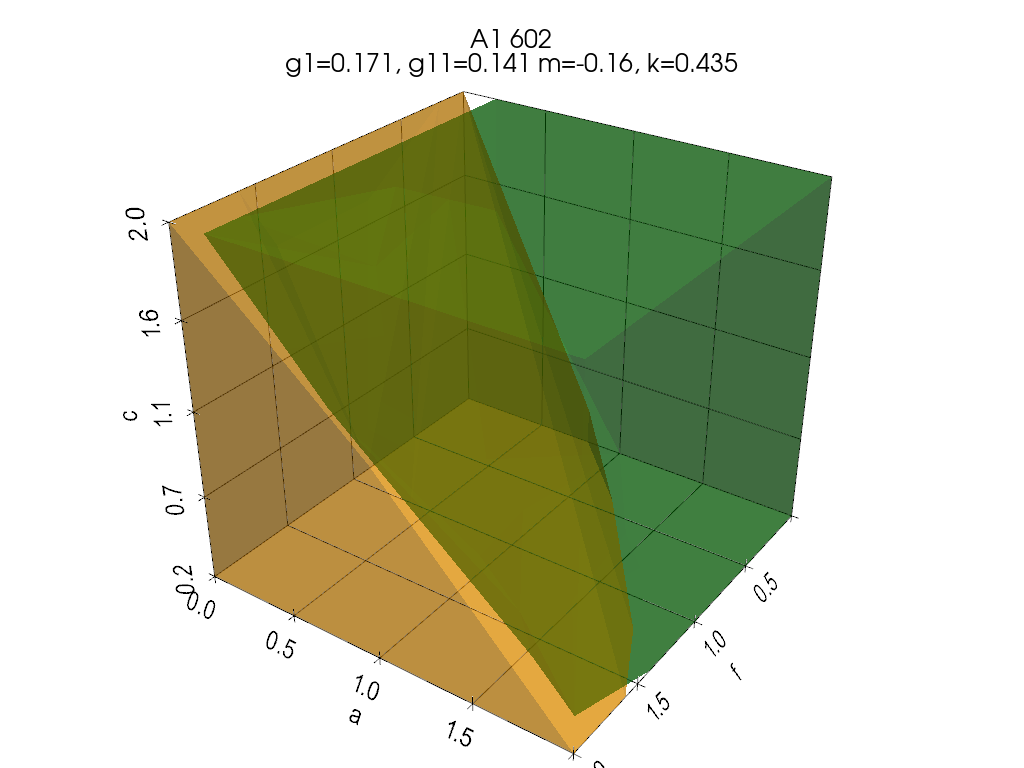

2026-05-28 09:54:53.092 ( 213.157s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557a2294e60): 3 degenerate triangles encountered, mesh quality suspect


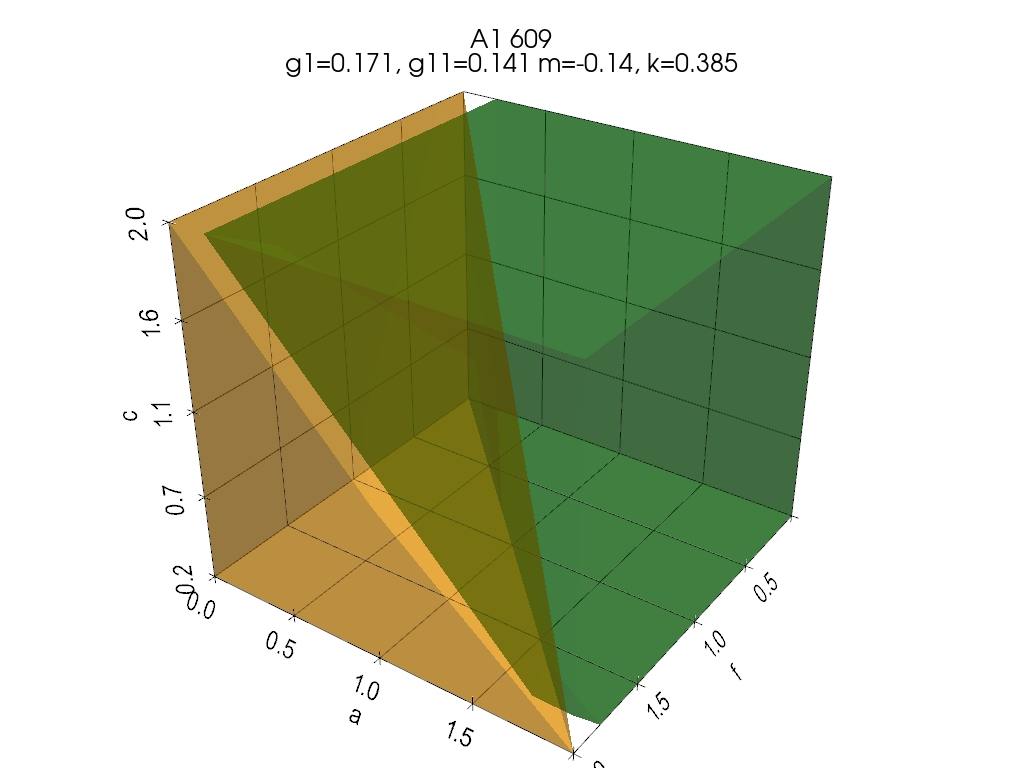

2026-05-28 09:54:53.848 ( 213.913s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557a58acf00): 3 degenerate triangles encountered, mesh quality suspect


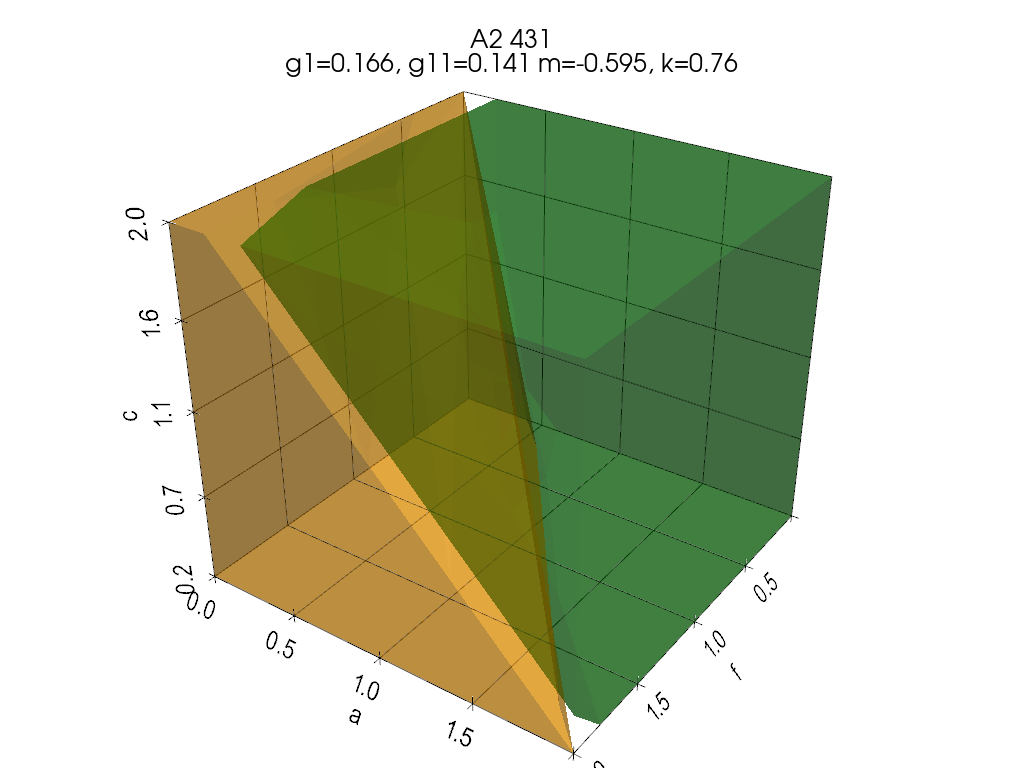

2026-05-28 09:54:54.659 ( 214.725s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557aa8f57d0): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:54:54.674 ( 214.740s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557a2302e40): 3 degenerate triangles encountered, mesh quality suspect


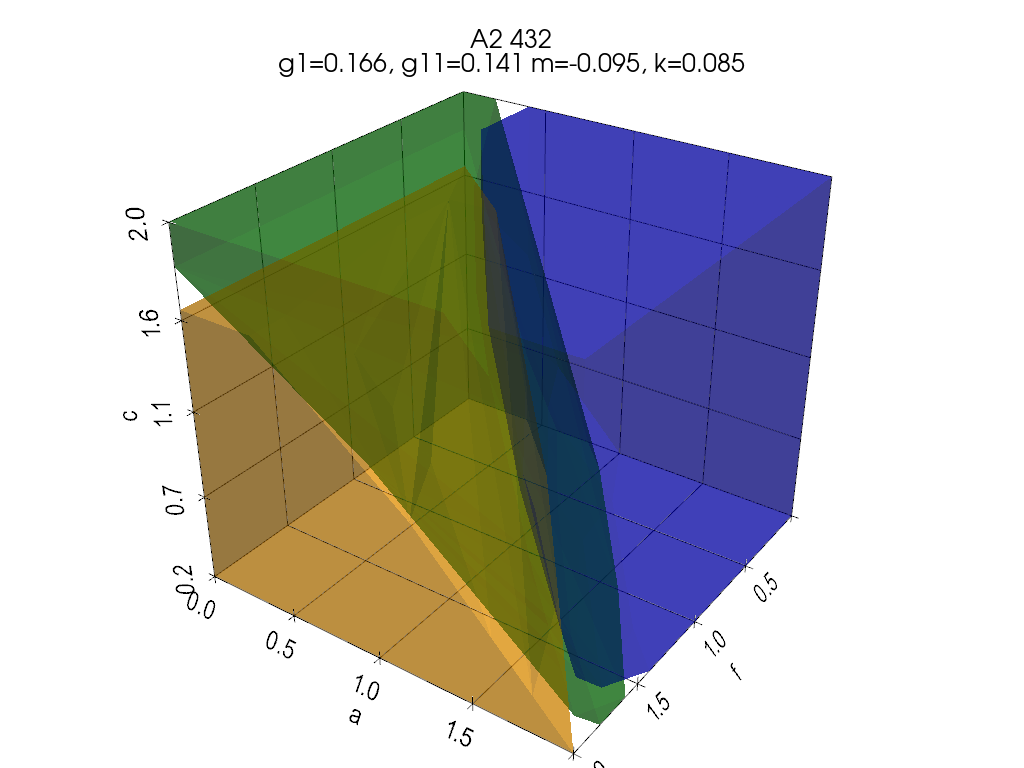

2026-05-28 09:54:55.438 ( 215.504s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557aa9dec50): 4 degenerate triangles encountered, mesh quality suspect


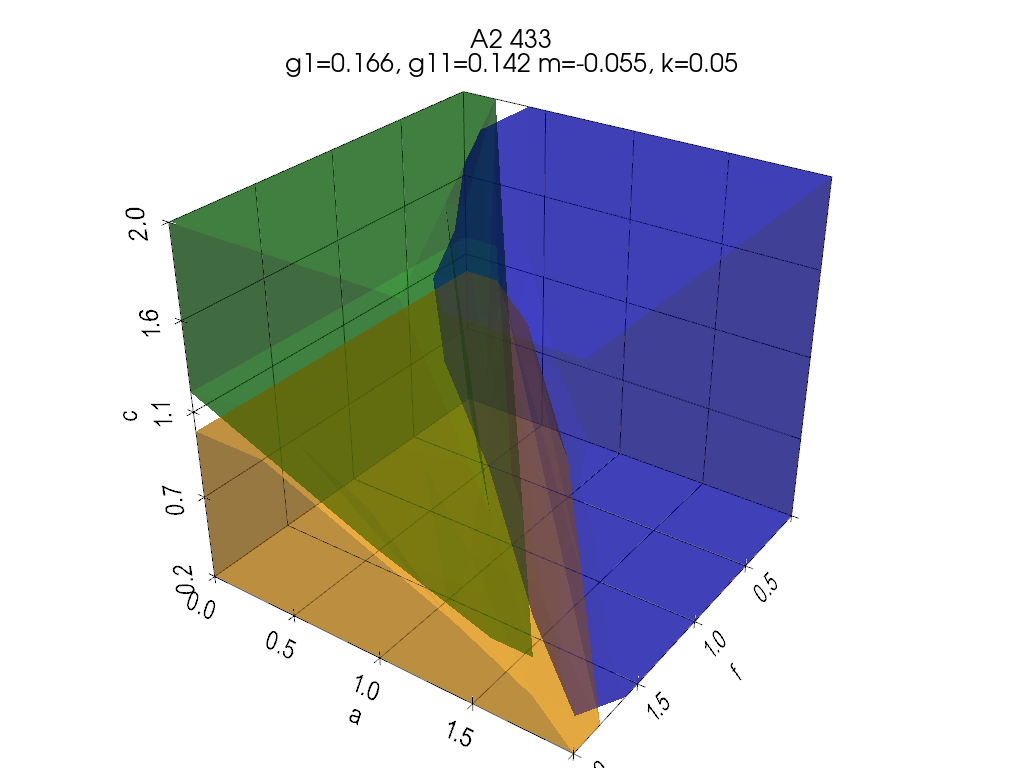

2026-05-28 09:54:56.200 ( 216.266s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557b3ae8e60): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:54:56.215 ( 216.281s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557b3ae8e60): 3 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:54:56.233 ( 216.298s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557b3ae8e60): 3 degenerate triangles encountered, mesh quality suspect


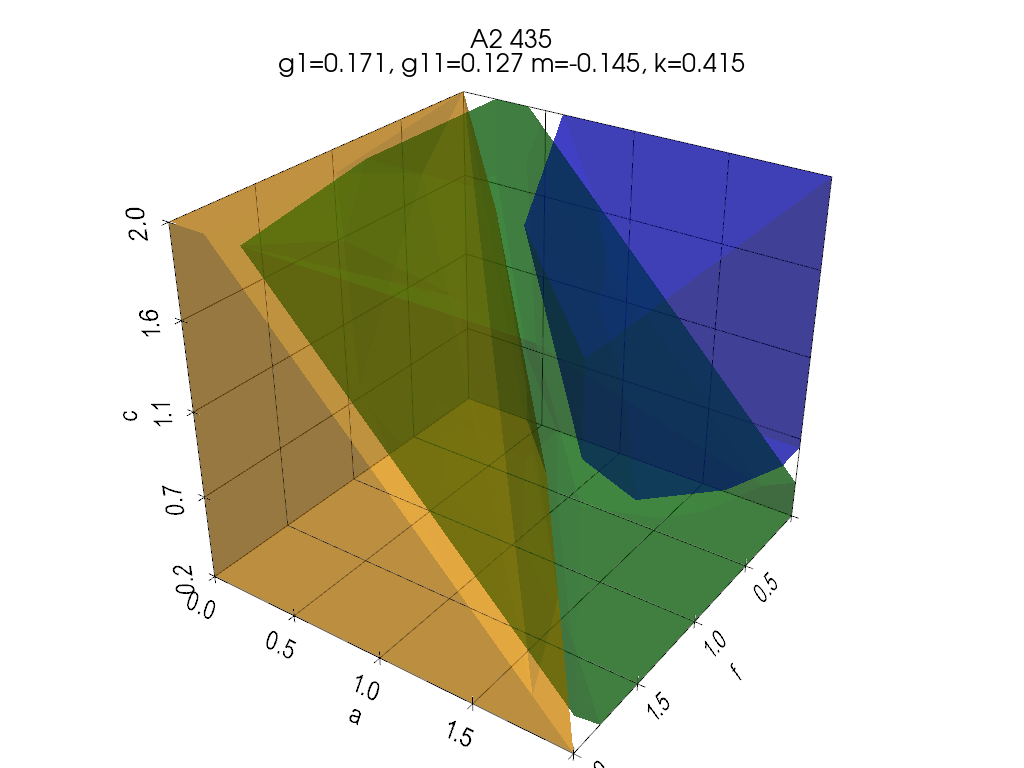

2026-05-28 09:54:57.002 ( 217.068s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557b80fba50): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:54:57.019 ( 217.085s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557b29e6f40): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:54:57.034 ( 217.099s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557b29e6f40): 1 degenerate triangles encountered, mesh quality suspect


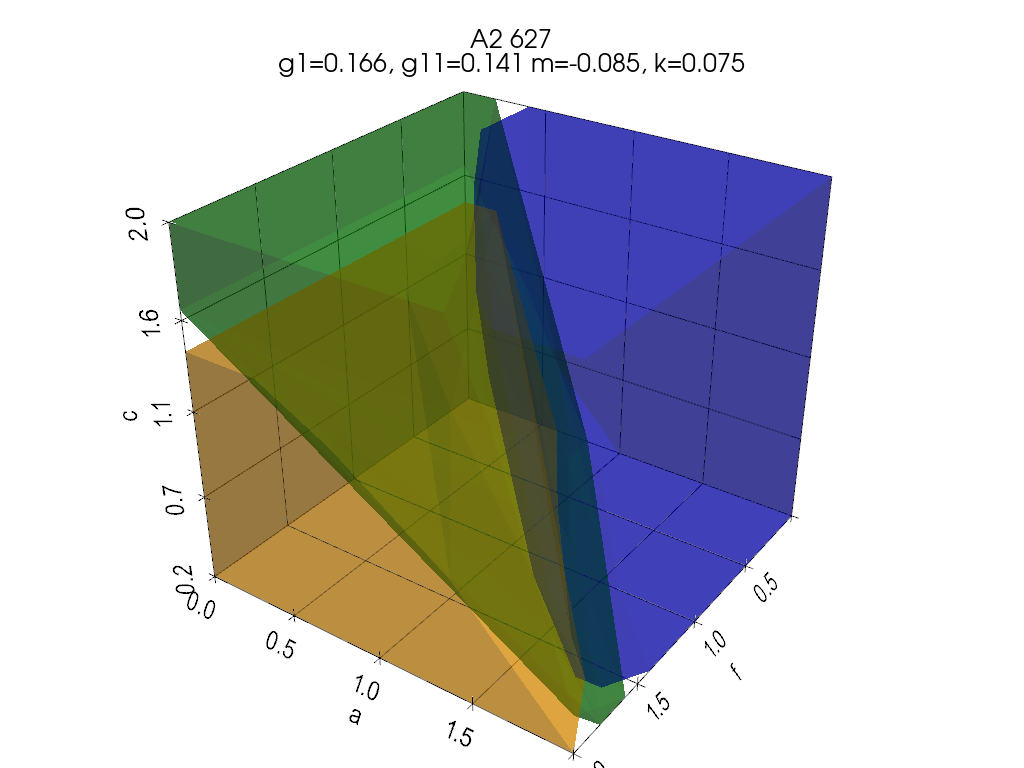

2026-05-28 09:54:57.786 ( 217.852s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557bc705c00): 1 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:54:57.802 ( 217.868s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557b28e9490): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:54:57.821 ( 217.886s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557bb664110): 3 degenerate triangles encountered, mesh quality suspect


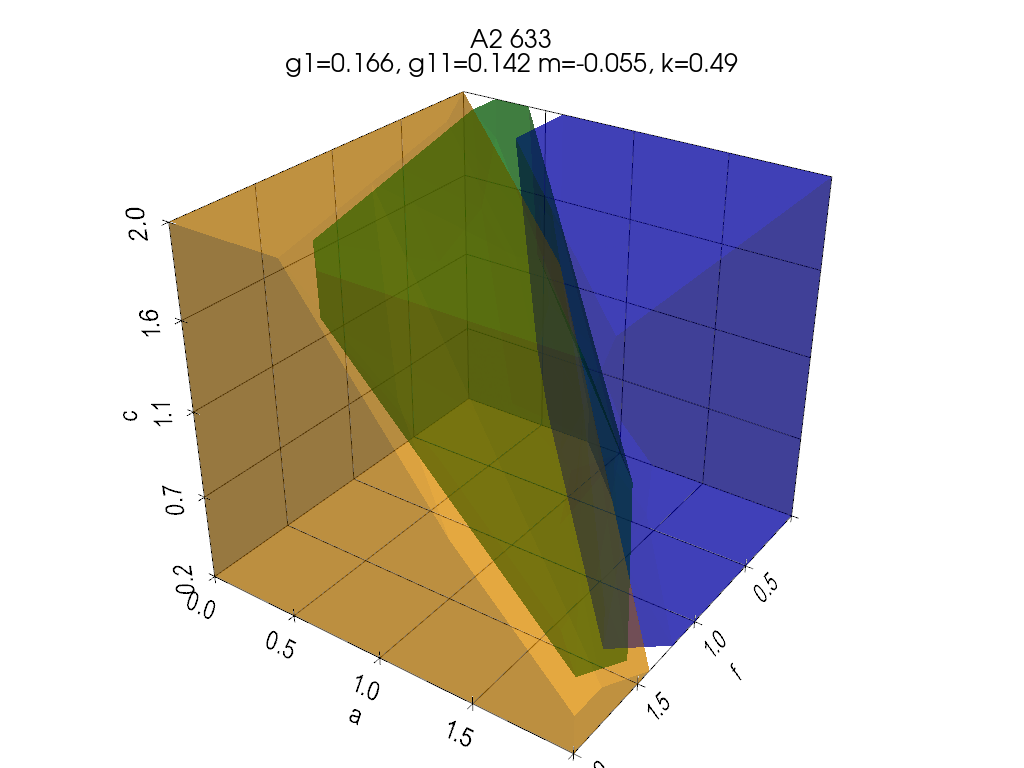

2026-05-28 09:54:58.589 ( 218.655s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557992809d0): 1 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:54:58.607 ( 218.673s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557992809d0): 1 degenerate triangles encountered, mesh quality suspect


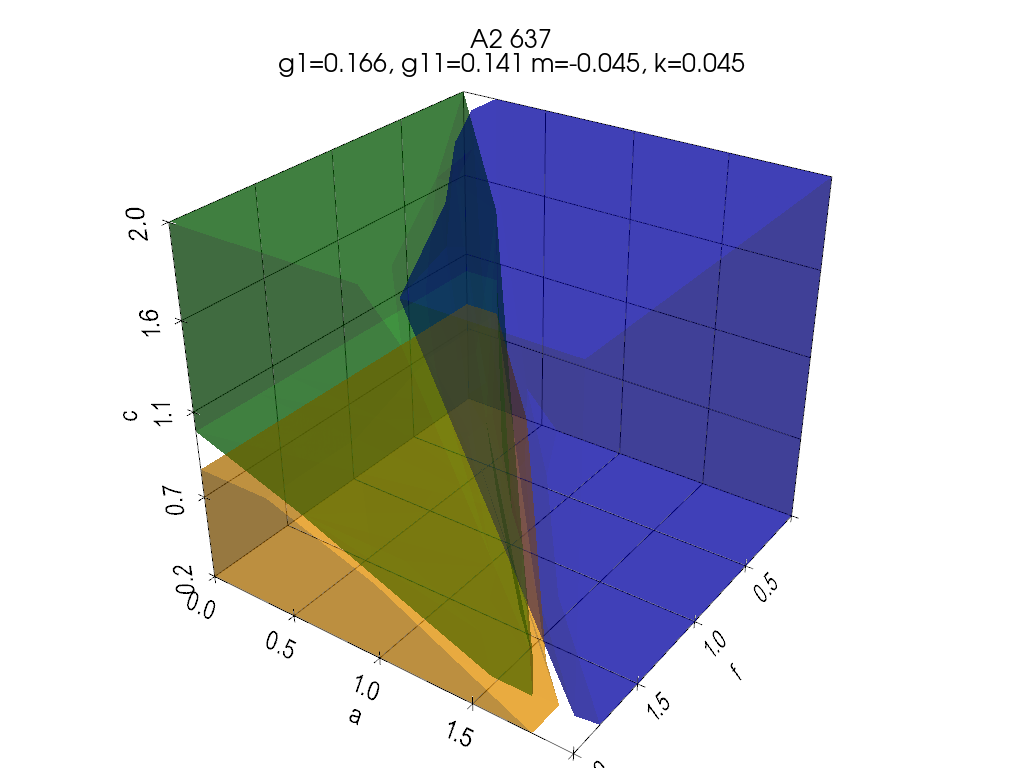

2026-05-28 09:54:59.348 ( 219.414s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557c5368600): 1 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:54:59.365 ( 219.431s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557c076e300): 2 degenerate triangles encountered, mesh quality suspect


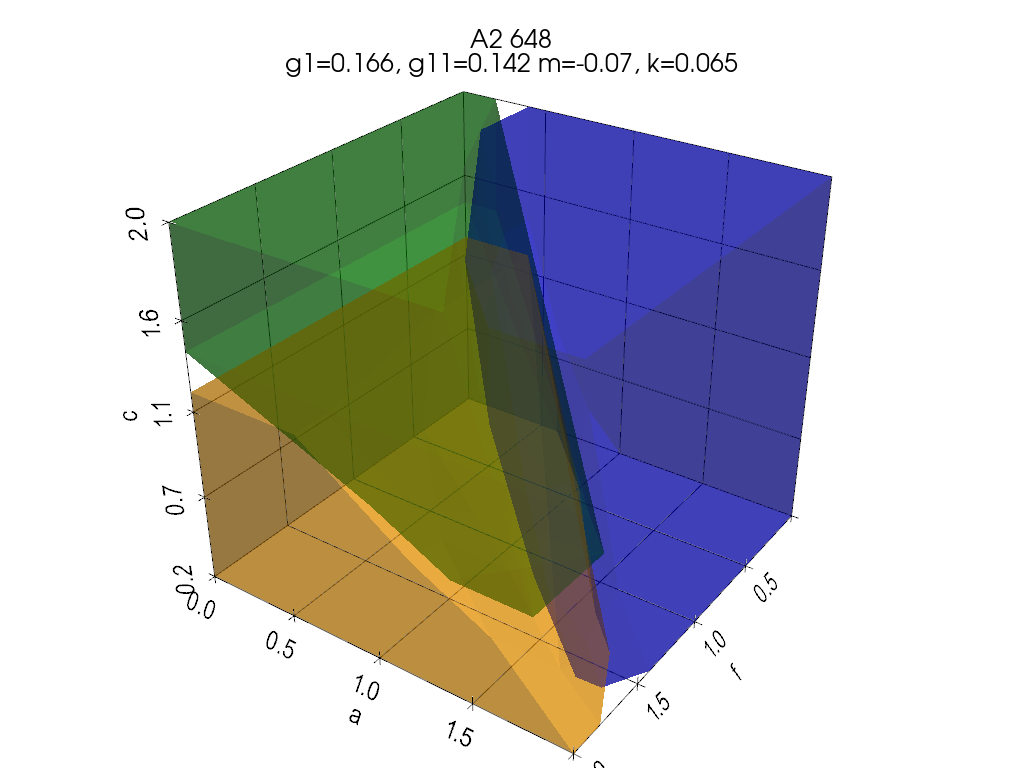

2026-05-28 09:55:00.124 ( 220.190s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557c8852f40): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:00.140 ( 220.206s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557c42e3280): 1 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:00.158 ( 220.224s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557c42e3280): 5 degenerate triangles encountered, mesh quality suspect


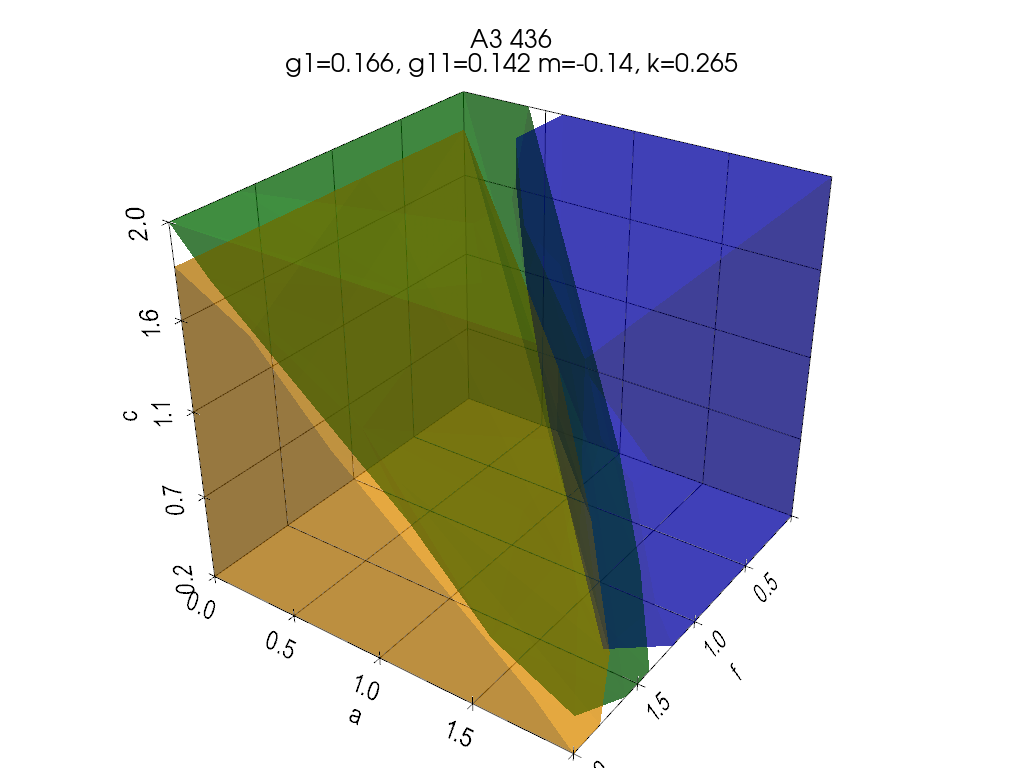

2026-05-28 09:55:00.917 ( 220.983s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557ce003200): 4 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:00.934 ( 221.000s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557ae44f4d0): 3 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:00.950 ( 221.016s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557ae44f4d0): 3 degenerate triangles encountered, mesh quality suspect


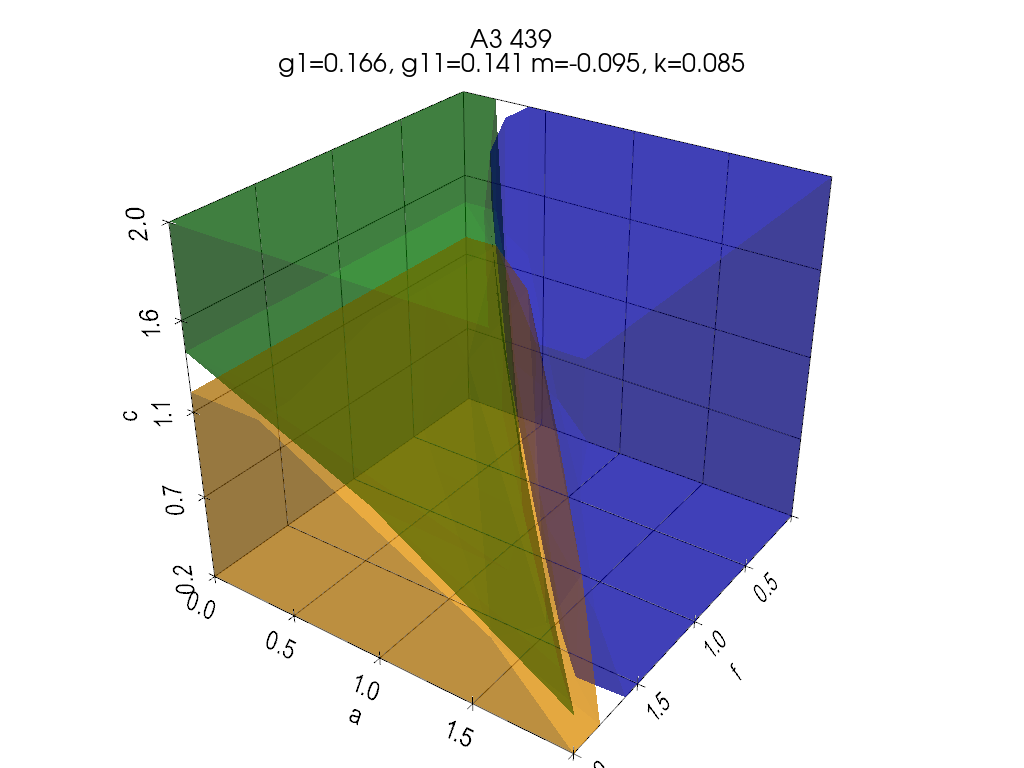

2026-05-28 09:55:01.679 ( 221.745s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557d1577380): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:01.725 ( 221.791s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557d1496fd0): 6 degenerate triangles encountered, mesh quality suspect


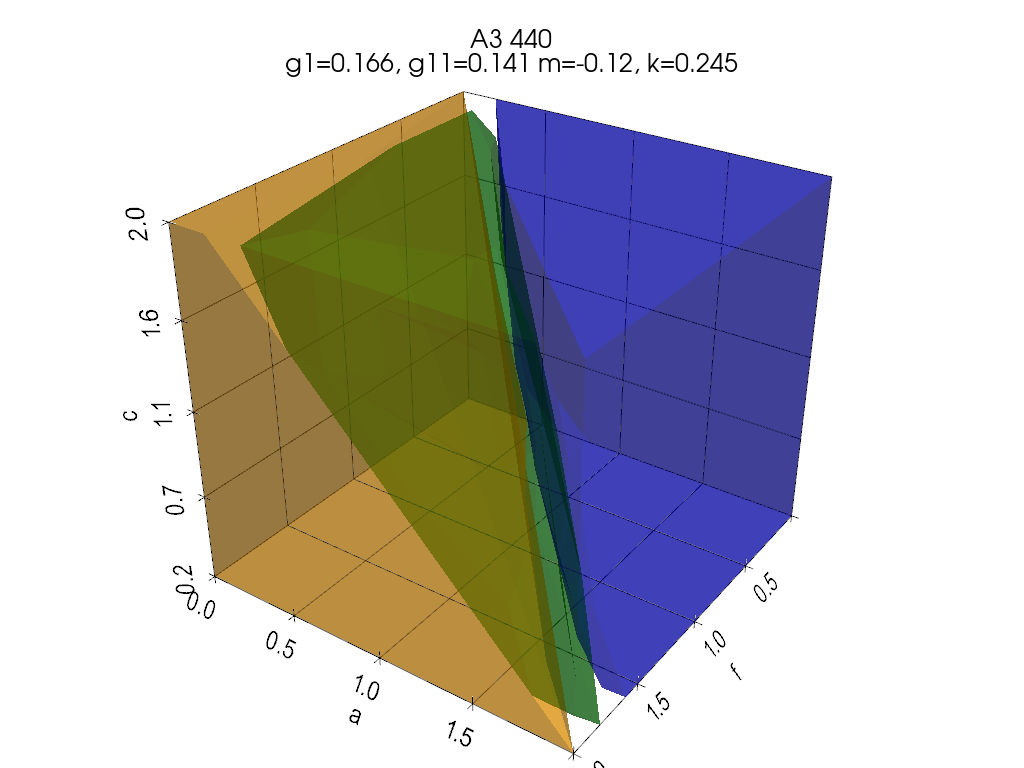

2026-05-28 09:55:02.477 ( 222.543s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557d6c878b0): 6 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:02.494 ( 222.560s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557d66e52b0): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:02.512 ( 222.578s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557d5c28830): 3 degenerate triangles encountered, mesh quality suspect


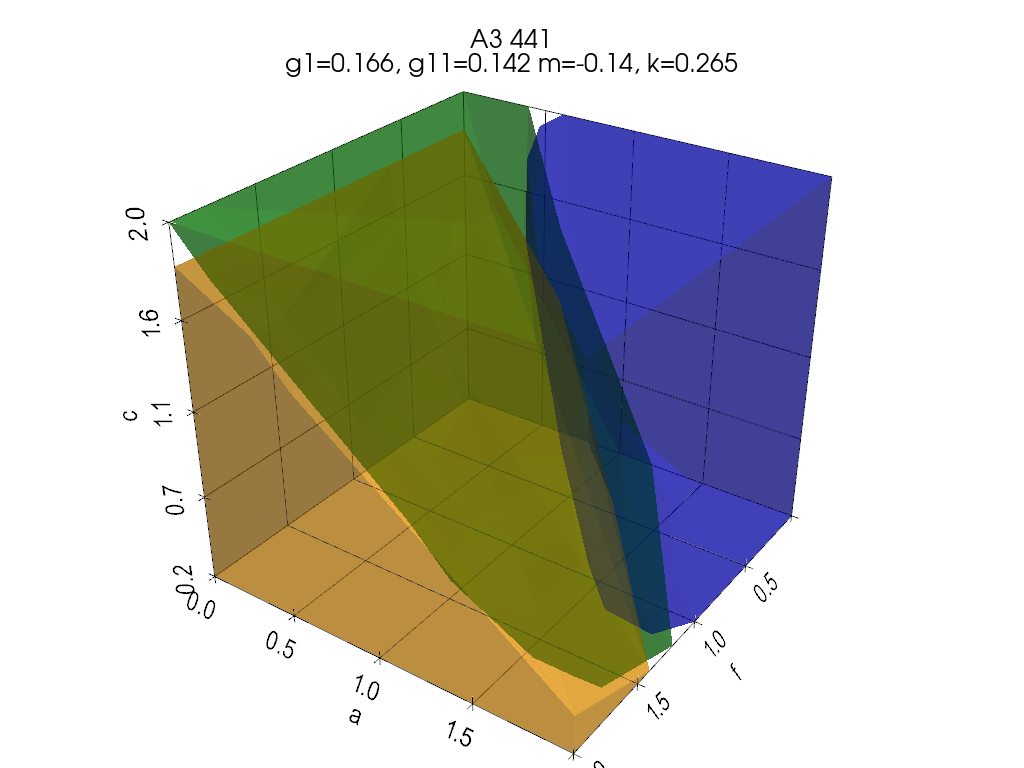

2026-05-28 09:55:03.274 ( 223.340s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557da28b000): 4 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:03.290 ( 223.356s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557dae042a0): 3 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:03.308 ( 223.374s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557dae042a0): 2 degenerate triangles encountered, mesh quality suspect


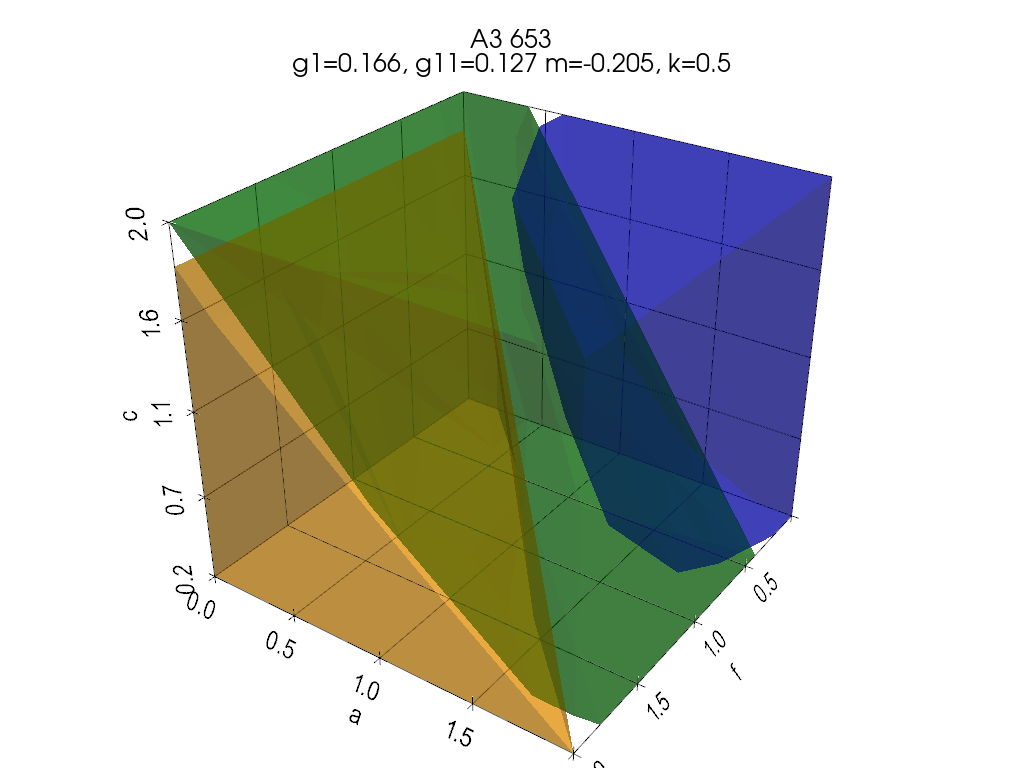

2026-05-28 09:55:04.060 ( 224.126s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557df8da780): 1 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:04.077 ( 224.143s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557df8da780): 1 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:04.093 ( 224.159s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557df8da780): 4 degenerate triangles encountered, mesh quality suspect


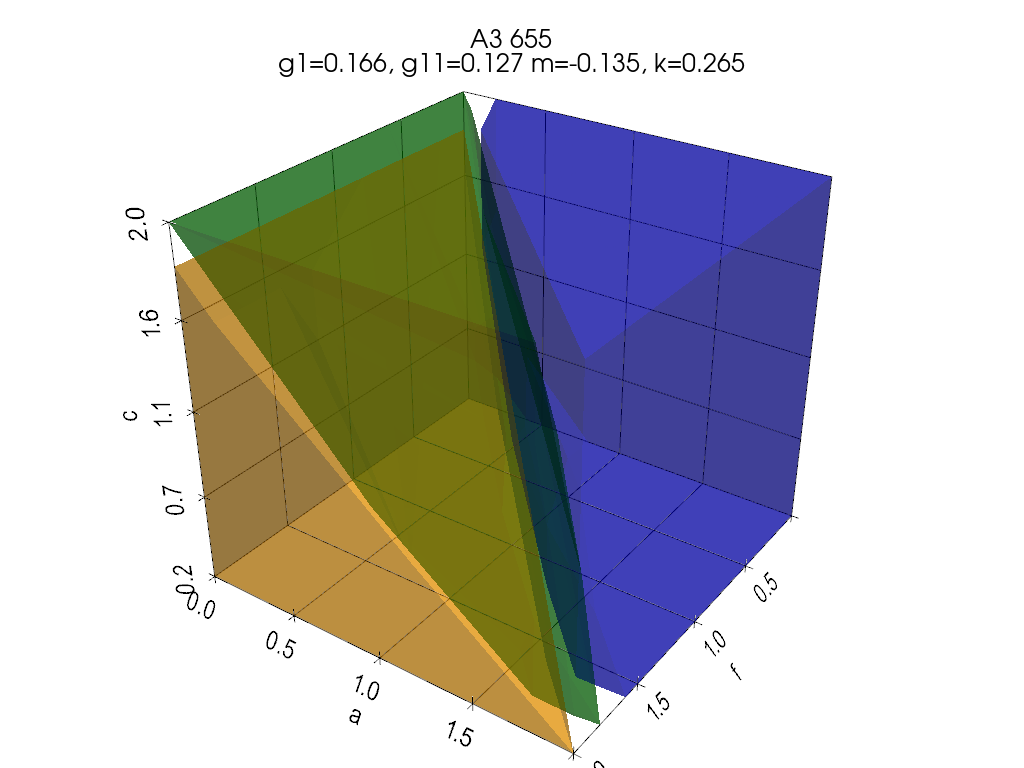

2026-05-28 09:55:04.853 ( 224.919s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557cce0e4b0): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:04.870 ( 224.936s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557de6dbed0): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:04.887 ( 224.952s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557de6dbed0): 2 degenerate triangles encountered, mesh quality suspect


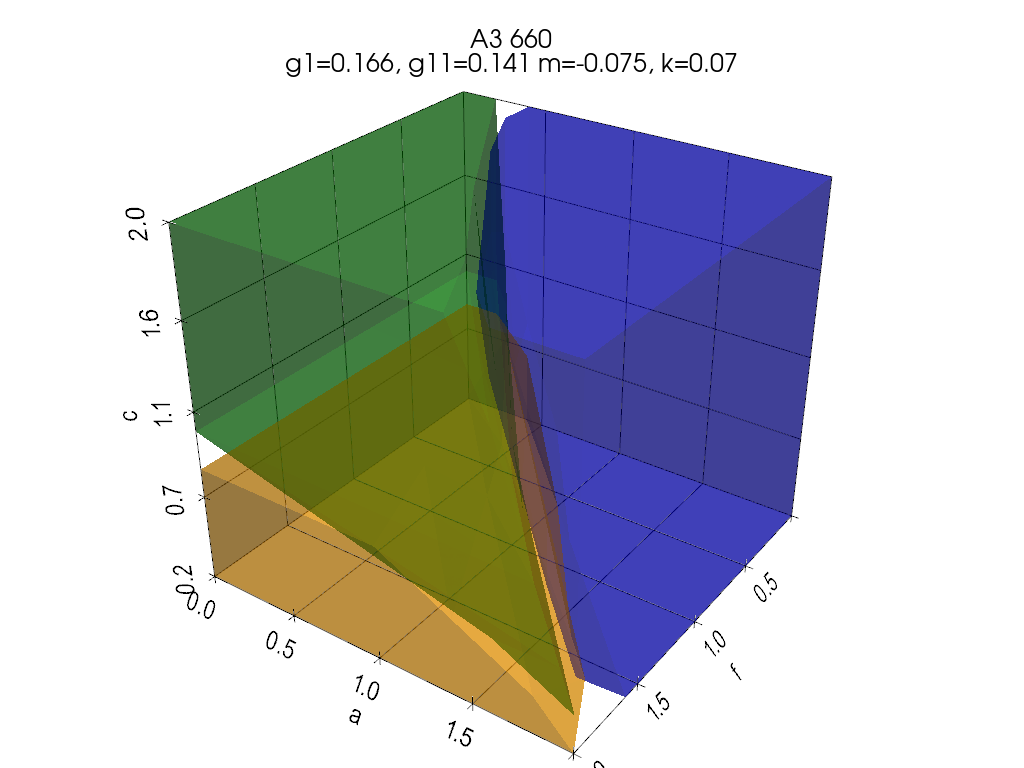

2026-05-28 09:55:05.611 ( 225.676s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557e846d8a0): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:05.628 ( 225.693s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557e2e85c10): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:05.643 ( 225.709s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557e744a870): 3 degenerate triangles encountered, mesh quality suspect


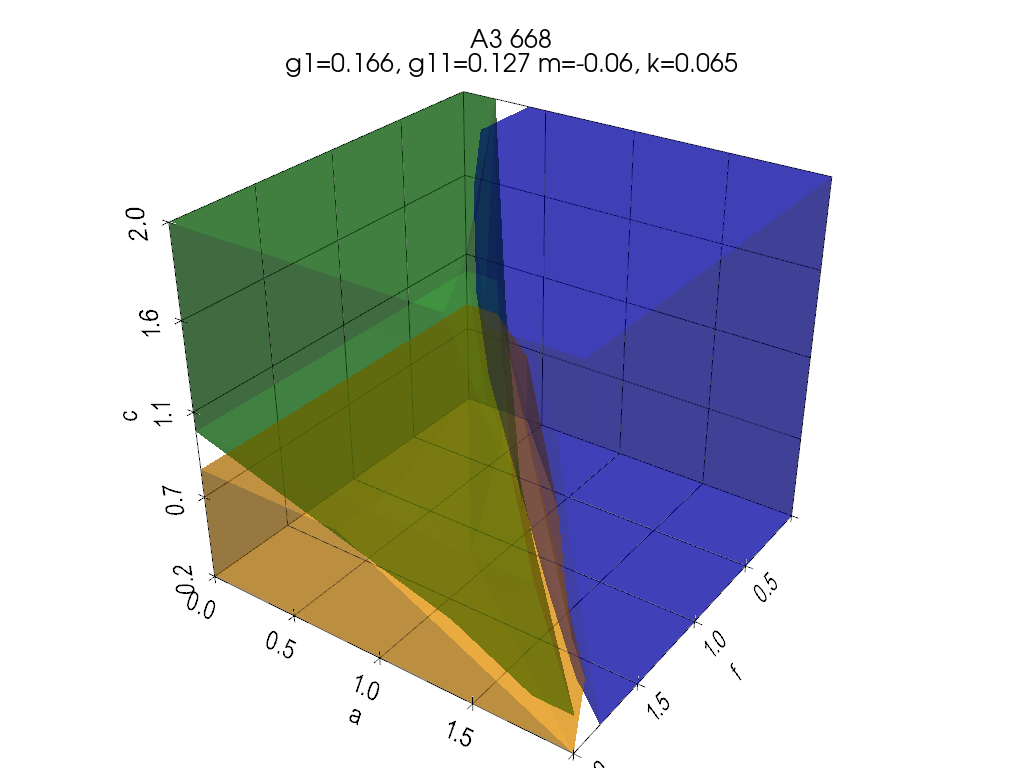

2026-05-28 09:55:06.371 ( 226.437s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557ecac16e0): 4 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:06.388 ( 226.454s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557ec4a18f0): 3 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:06.405 ( 226.471s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557ec4a18f0): 2 degenerate triangles encountered, mesh quality suspect


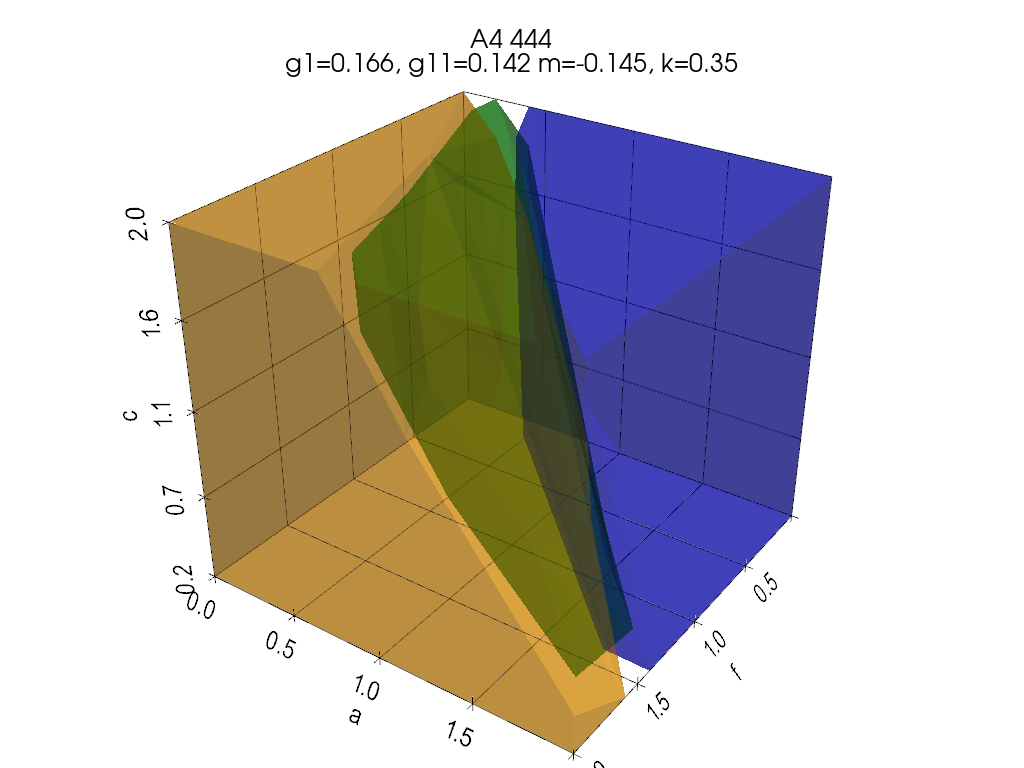

2026-05-28 09:55:07.167 ( 227.232s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557f10abd40): 3 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:07.183 ( 227.249s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557f0007dd0): 1 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:07.194 ( 227.260s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557f1087040): 1 degenerate triangles encountered, mesh quality suspect


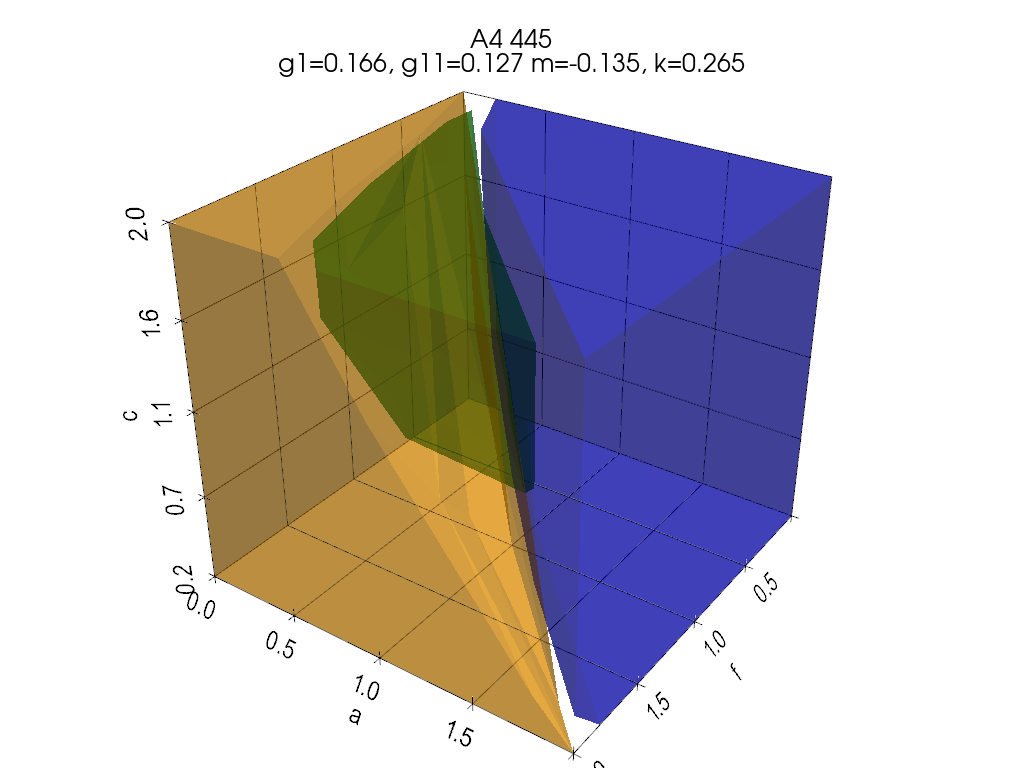

2026-05-28 09:55:07.921 ( 227.987s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557f5748250): 1 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:07.938 ( 228.004s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557f0026ff0): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:07.955 ( 228.020s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557f44d7020): 1 degenerate triangles encountered, mesh quality suspect


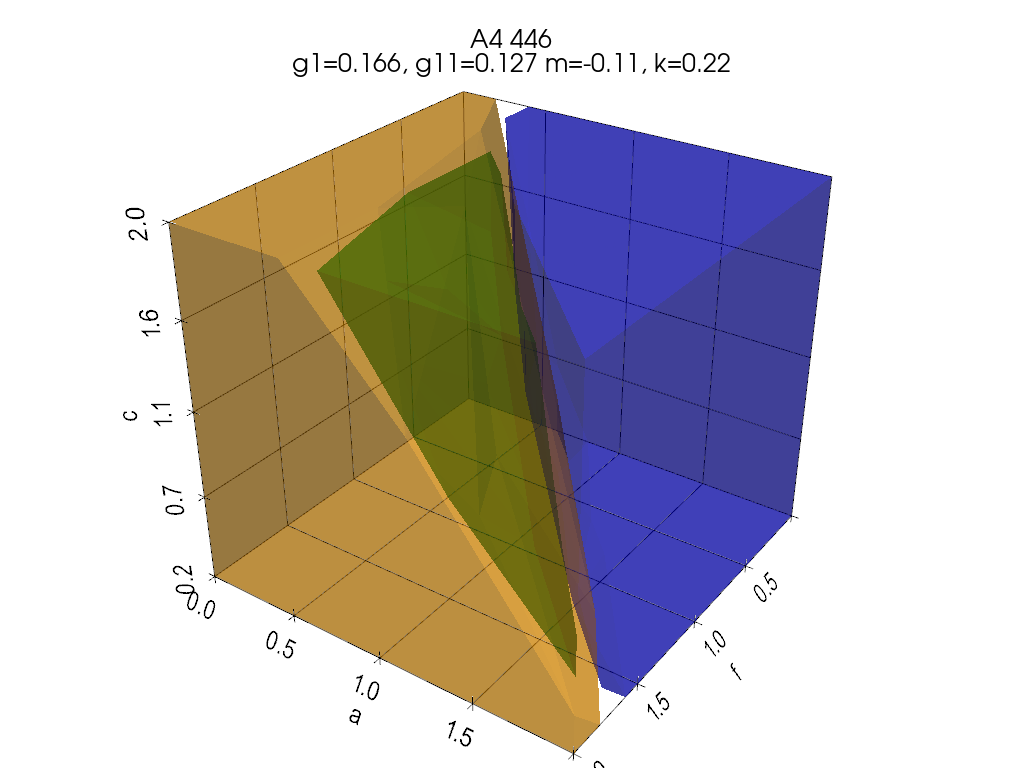

2026-05-28 09:55:08.681 ( 228.747s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557f9cede30): 4 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:08.698 ( 228.764s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557f9cd7170): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:08.714 ( 228.780s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557f9cd7170): 5 degenerate triangles encountered, mesh quality suspect


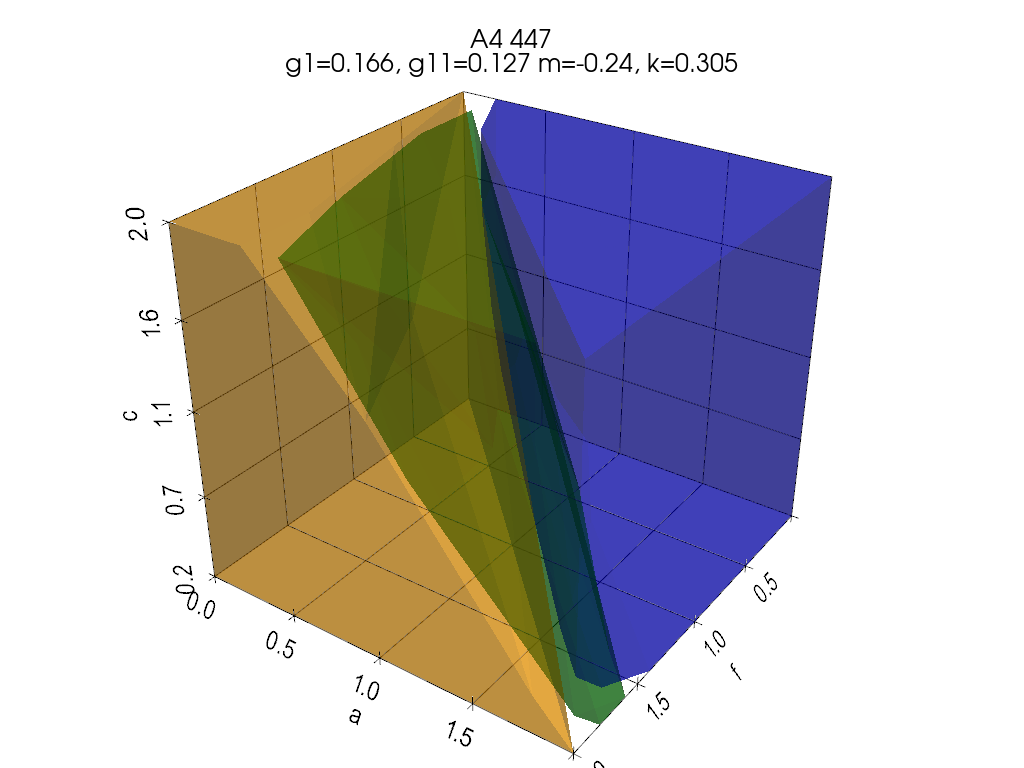

2026-05-28 09:55:09.479 ( 229.544s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557e2cb6990): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:09.512 ( 229.578s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5557fe3a2240): 2 degenerate triangles encountered, mesh quality suspect


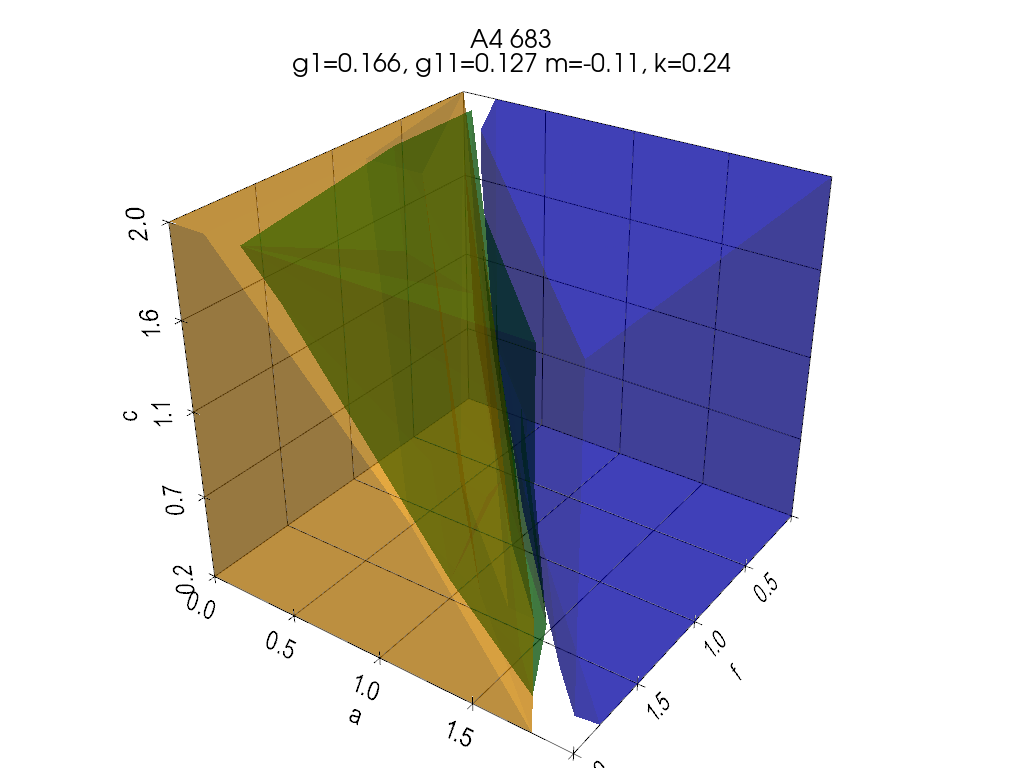

2026-05-28 09:55:10.284 ( 230.350s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x555802967c30): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:10.302 ( 230.367s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5558018414a0): 1 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:10.317 ( 230.383s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x5558018414a0): 5 degenerate triangles encountered, mesh quality suspect


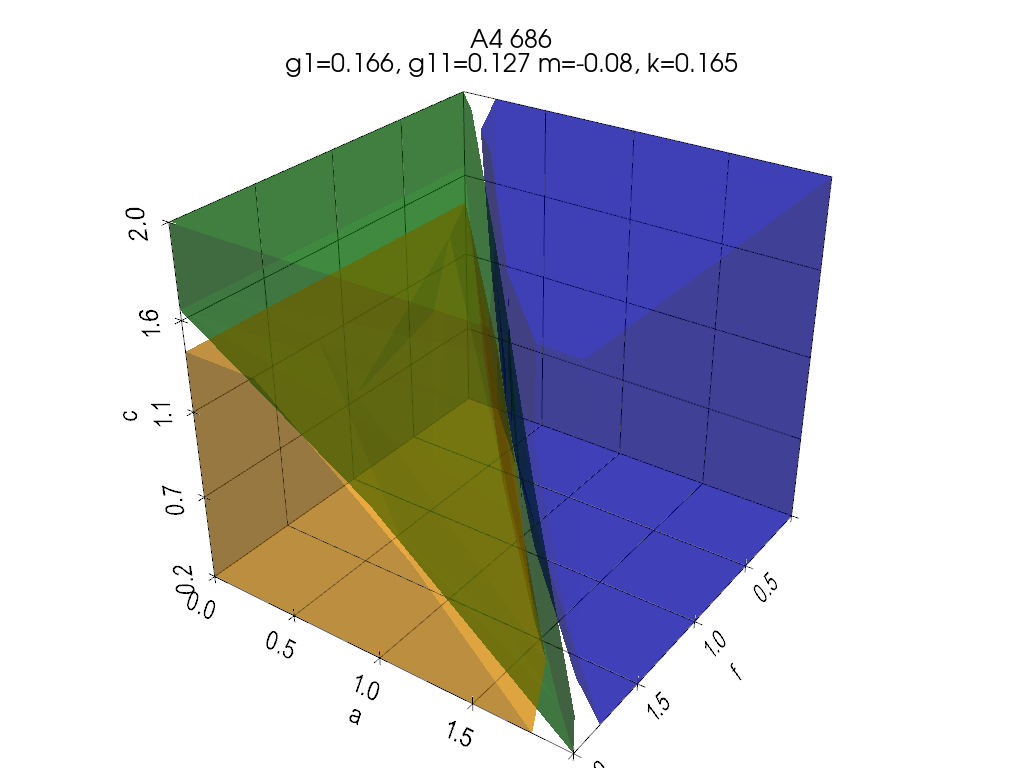

2026-05-28 09:55:11.076 ( 231.142s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x555806f3bcd0): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:11.099 ( 231.164s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x555806f3bcd0): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:11.119 ( 231.184s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x555801891d80): 2 degenerate triangles encountered, mesh quality suspect


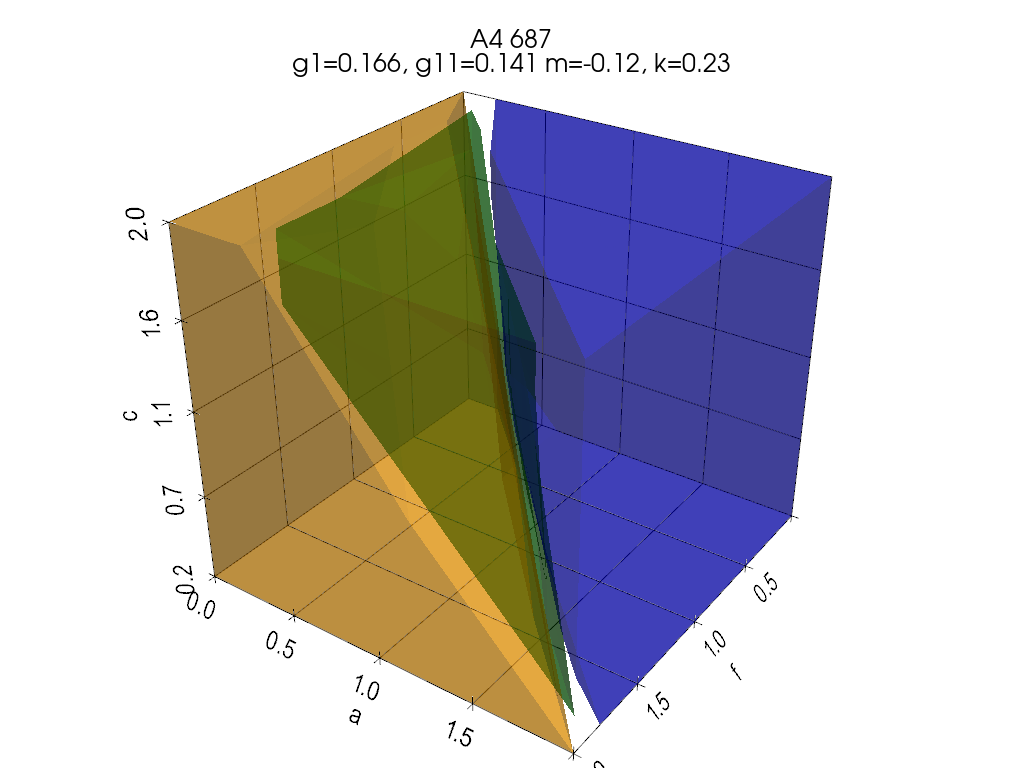

2026-05-28 09:55:12.169 ( 232.235s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x55580b5dc1b0): 4 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:12.186 ( 232.251s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x55580b5dc1b0): 2 degenerate triangles encountered, mesh quality suspect
2026-05-28 09:55:12.202 ( 232.268s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x55580b5dc1b0): 2 degenerate triangles encountered, mesh quality suspect


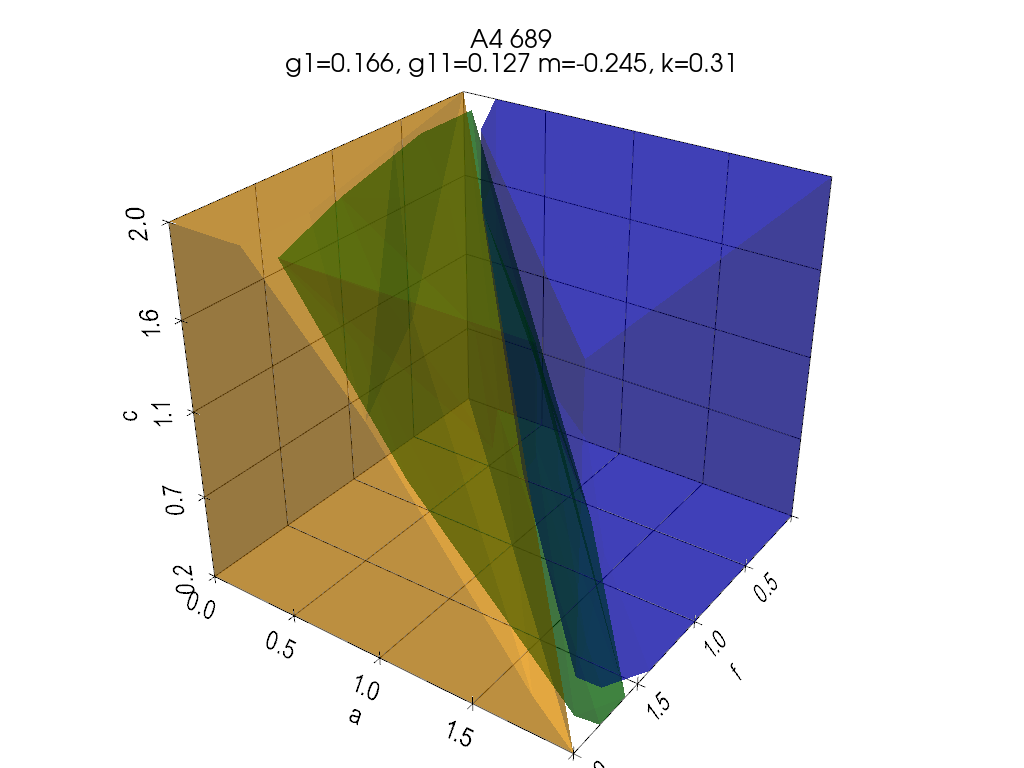

2026-05-28 09:55:12.982 ( 233.048s) [    7FFFF7FE8240]      vtkDelaunay3D.cxx:510   WARN| vtkDelaunay3D (0x55580eb53c30): 2 degenerate triangles encountered, mesh quality suspect


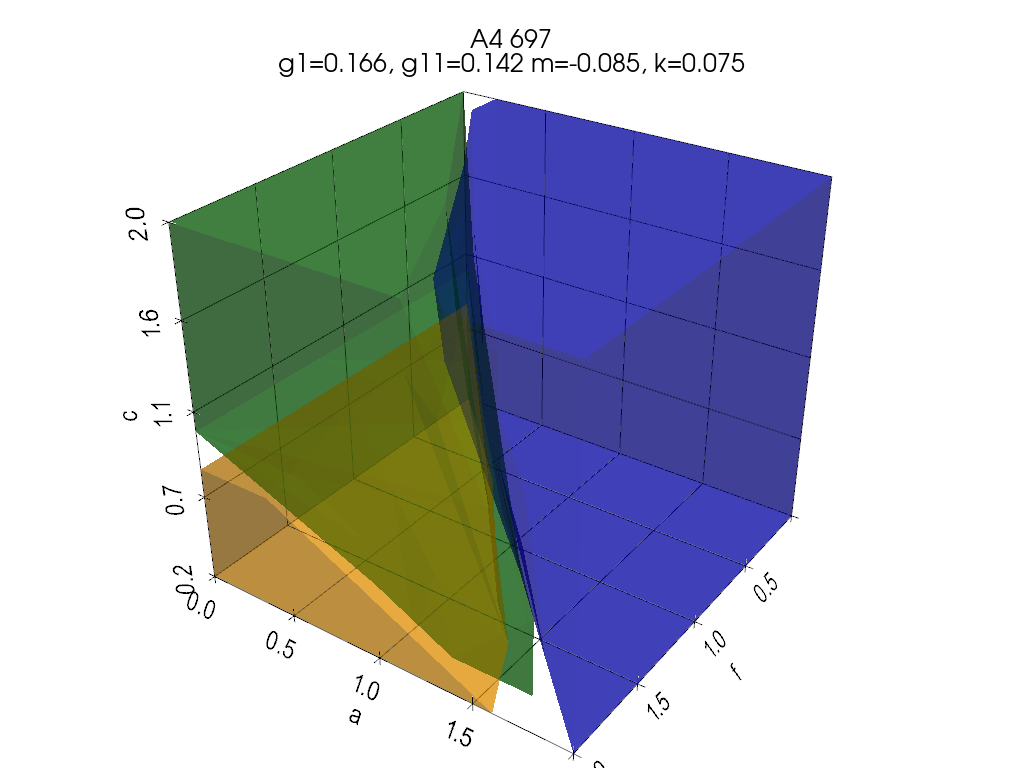

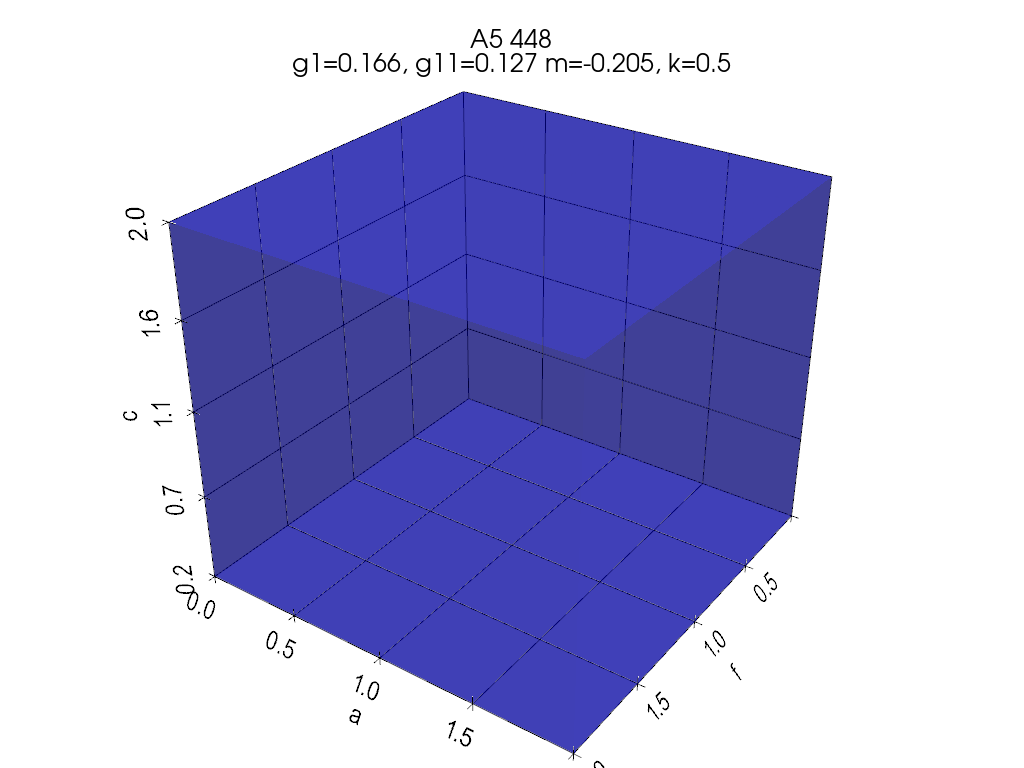

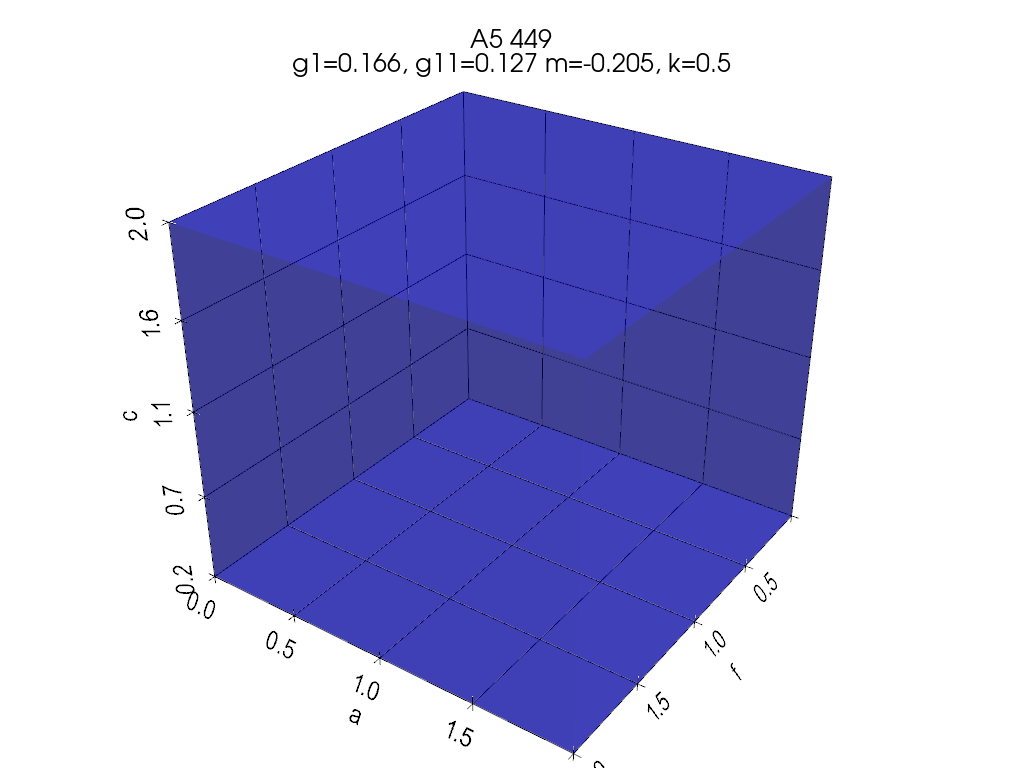

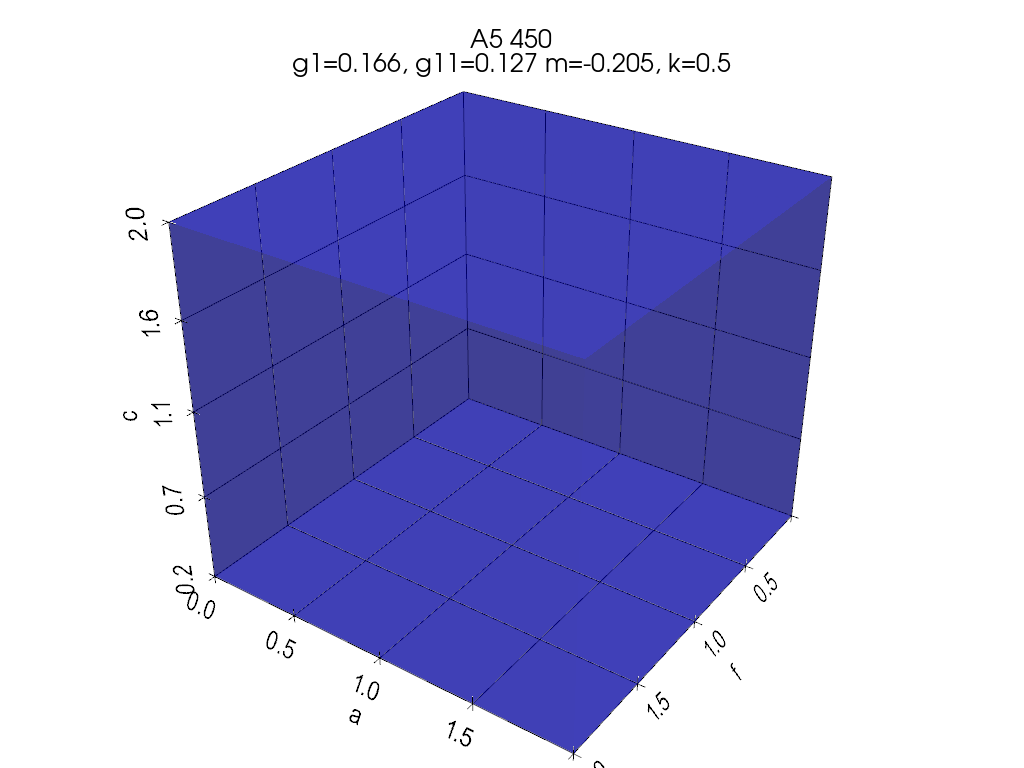

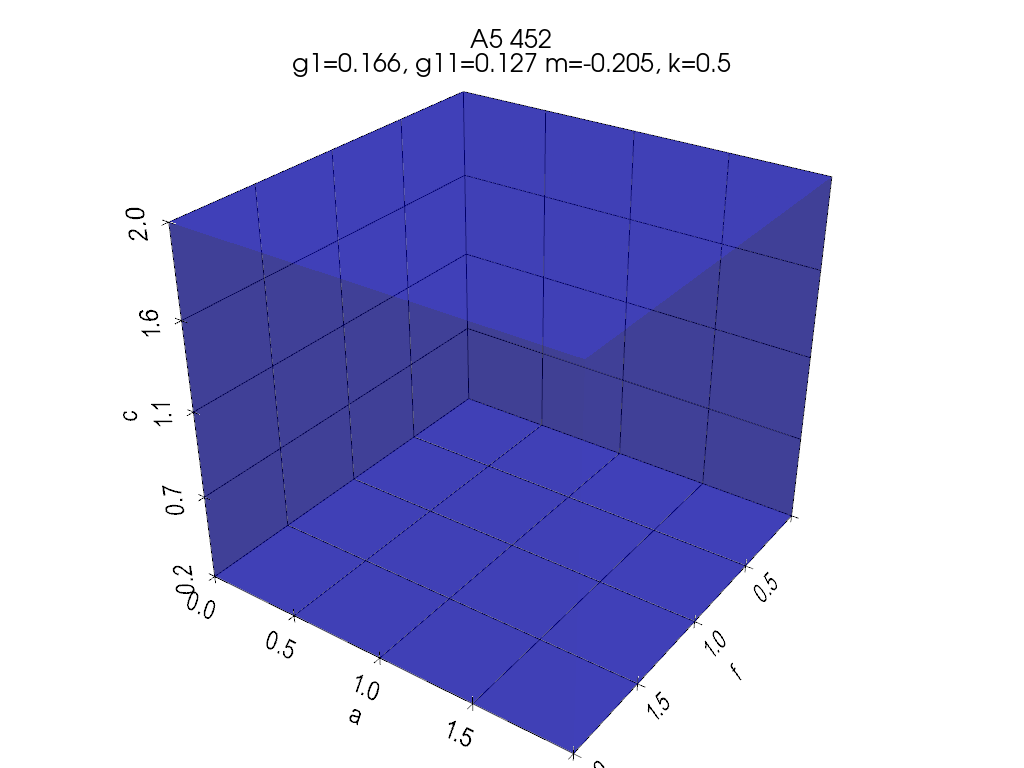

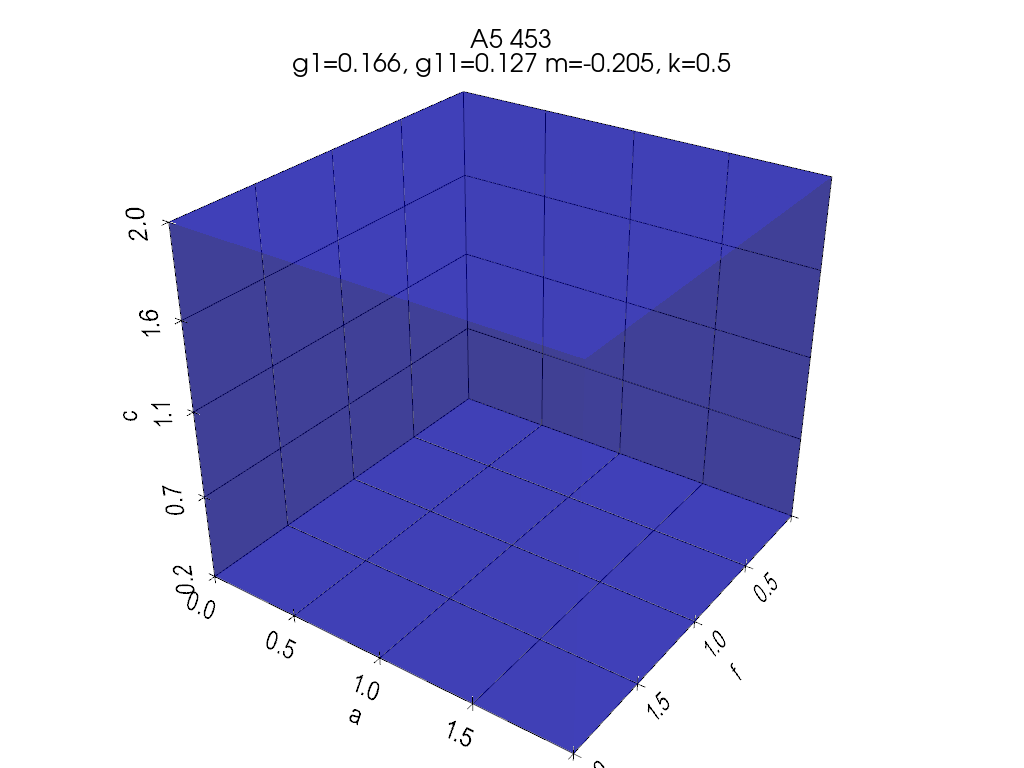

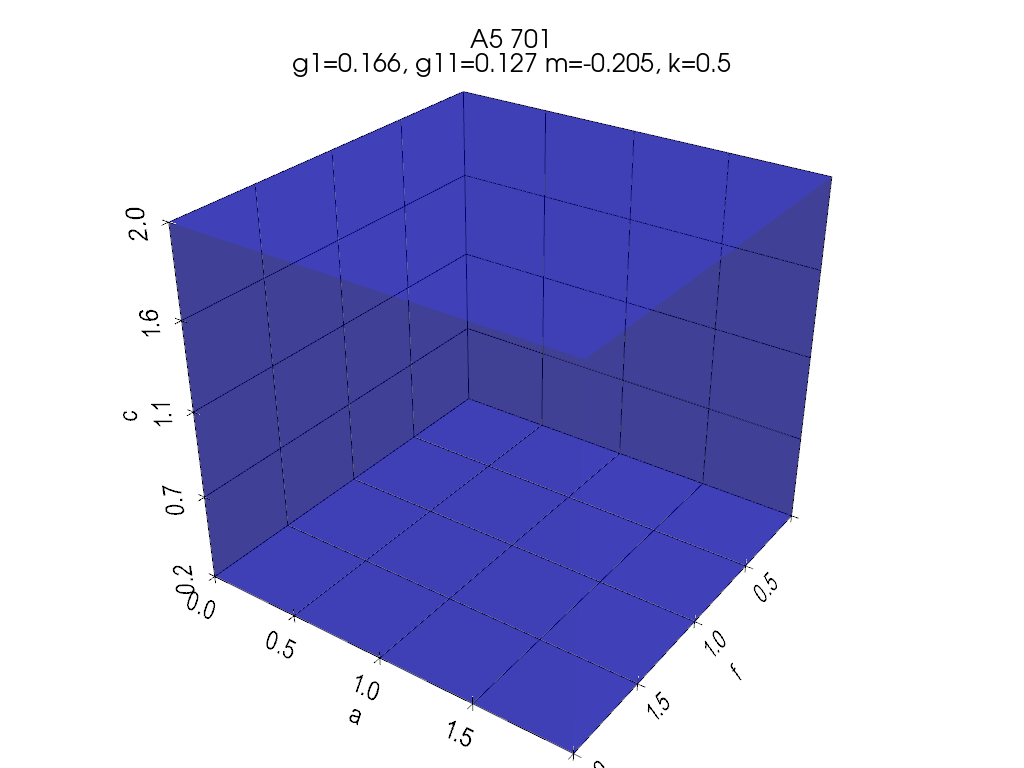

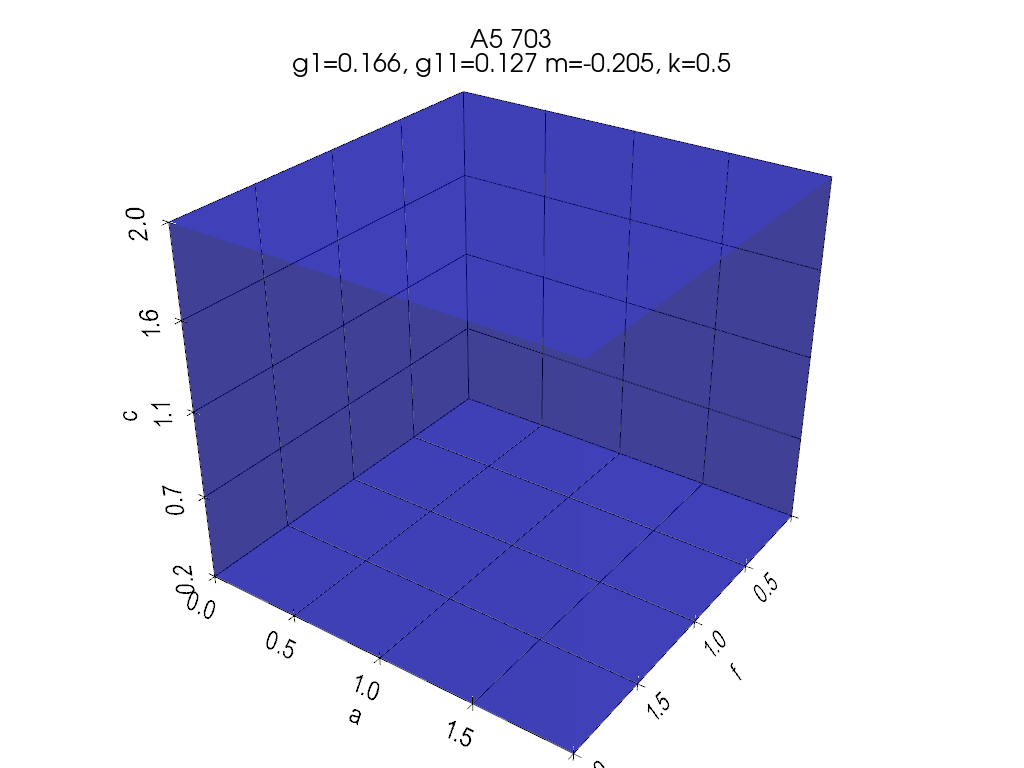

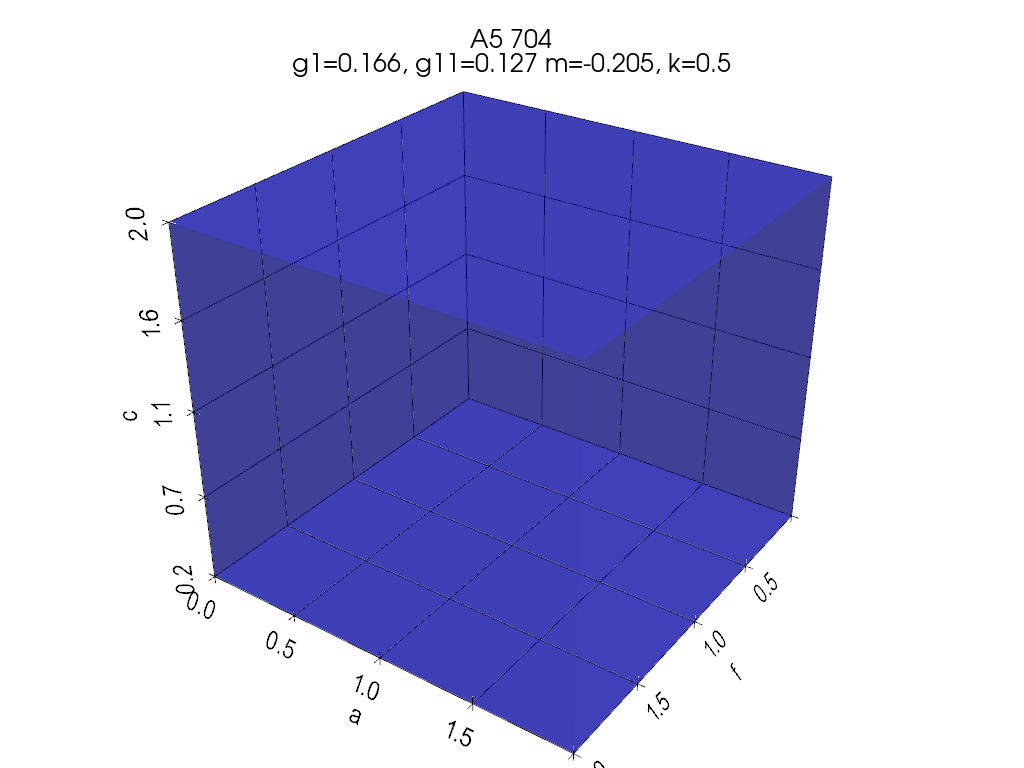

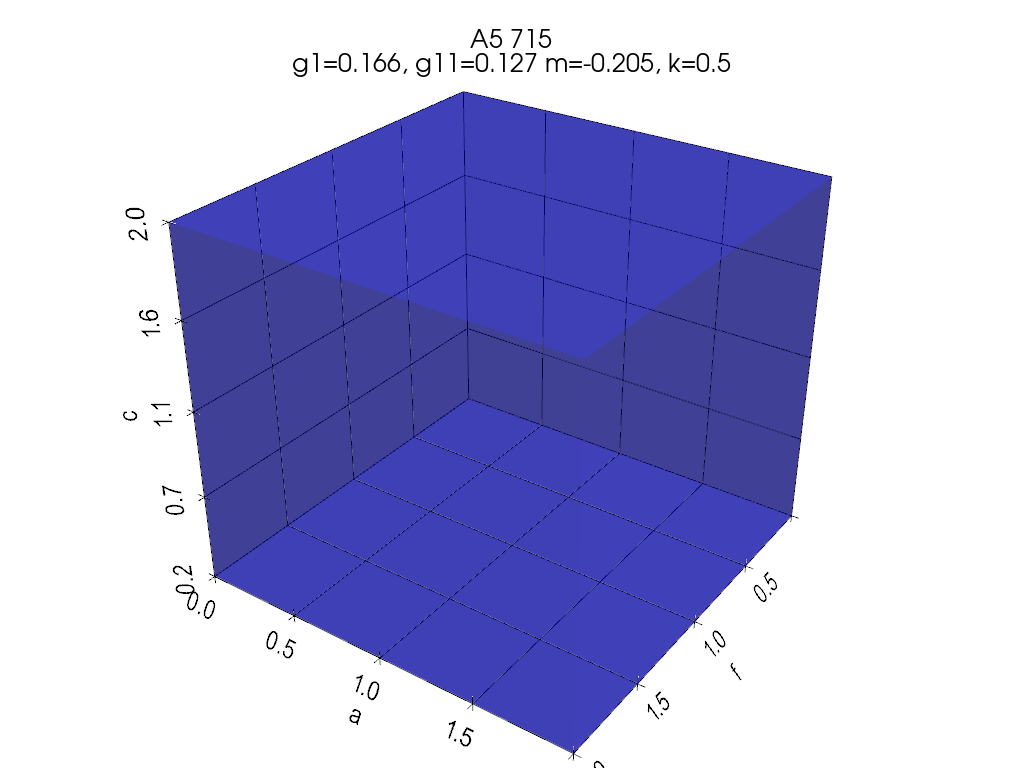

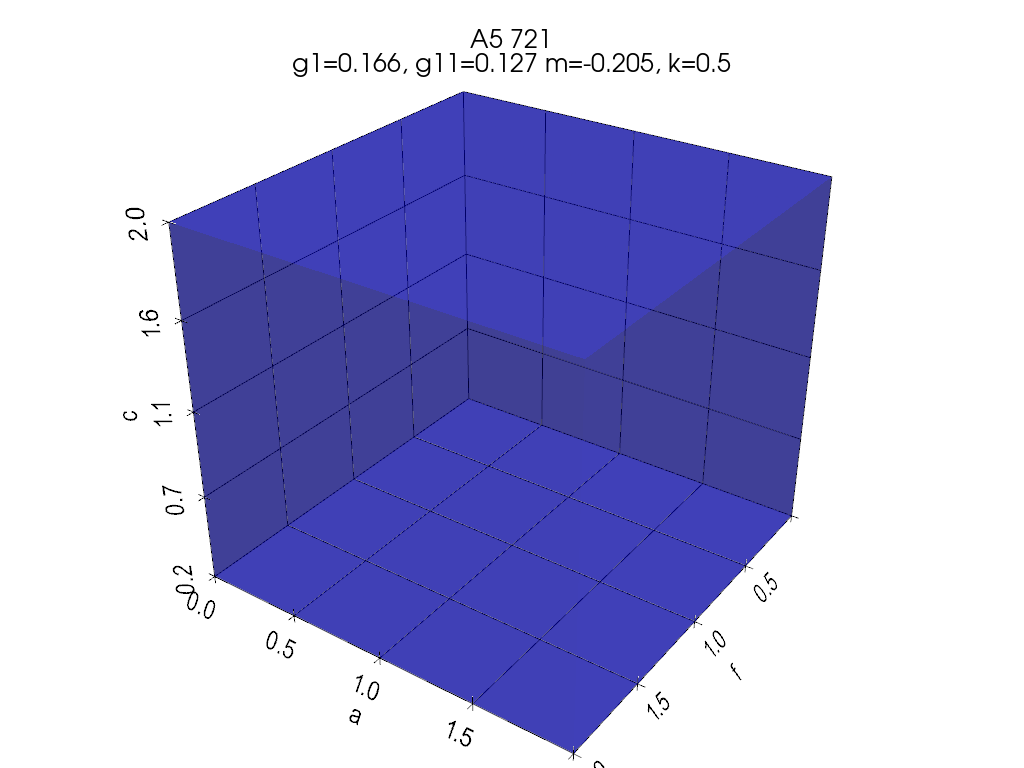

In [21]:
cs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

for idx in range(0, len(best_results)):
    curr_group = groups.index(best_results.loc[idx, "group"])
    curr_id = best_results.loc[idx, "id"]
    curr_g1 = best_results.loc[idx, "g1"]
    curr_g11 = best_results.loc[idx, "g11"]
    curr_m = best_results.loc[idx, "m"]
    curr_k = best_results.loc[idx, "k"]
    curr_b = best_results.loc[idx, "b"]

    temp = results[(results["group"] == groups[curr_group]) & (results["g1"] == curr_g1) & (results["g11"] == curr_g11) 
                        & (results["m"] == curr_m) & (results["k"] == curr_k) & (results["b"] == curr_b)]
    temp = temp[["c", "a", "f", "winner"]]
    temp = temp.drop_duplicates()
    temp = temp.groupby(["c", "a", "f"]).max().reset_index() # This just drops the separation between mice -- all mice will be the same, so this could be max, min, whatever
    
    # Dataframes associated with d values
    dfs = [pd.pivot(temp[temp["c"] == c], index="a", columns="f", values="winner") for c in cs]

    plot_3d(cs, dfs, curr_group, curr_id, stretch=0)

## Get region volumes for all mice

In [14]:
vols = get_vols()
if volume_save_path:
    vols.to_csv("{}best_fit_volumes.csv".format(volume_save_path), index=False)
vols

,group,id,c1,c11,te
0,Grp. A1 B6 (100% C1),424,0.912,0.000,2.730
1,Grp. A1 B6 (100% C1),425,0.814,0.000,2.824
2,Grp. A1 B6 (100% C1),427,0.814,0.000,2.824
3,Grp. A1 B6 (100% C1),600,0.814,0.000,2.824
4,Grp. A1 B6 (100% C1),601,0.870,0.000,2.768
5,Grp. A1 B6 (100% C1),602,1.332,0.000,2.278
6,Grp. A1 B6 (100% C1),609,0.834,0.000,2.764
7,Grp. A2 B6 (80% C1; 20% C11),431,1.100,0.000,2.502
8,Grp. A2 B6 (80% C1; 20% C11),432,1.060,1.668,0.500
9,Grp. A2 B6 (80% C1; 20% C11),433,0.856,1.848,0.804


## Get the volumes of the overlapping regions across mice

In [38]:
overlaps = []
for g in [0, 1, 2, 3, 4]:
    overlaps += [[groups[g]] + get_overlap_vols(g)]
overlaps += [["A1-A4"] + get_overlap_vols(-1)]
overlaps = pd.DataFrame(overlaps, columns=["group", "c1", "c11", "te"])
overlaps["%c1"] = overlaps["c1"] / 4
overlaps["%c11"] = overlaps["c11"] / 4
overlaps["%te"] = overlaps["te"] / 4
if volume_save_path:
    overlaps.to_csv("{}overlap_volumes.csv".format(volume_save_path), index=False)
overlaps

,group,c1,c11,te,%c1,%c11,%te
0,Grp. A1 B6 (100% C1),0.81,0.00,2.28,0.2025,0.0000,0.5700
1,Grp. A2 B6 (80% C1; 20% C11),0.55,0.61,0.04,0.1375,0.1525,0.0100
2,Grp. A3 B6 (50% C1; 50% C11),0.55,0.90,0.38,0.1375,0.2250,0.0950
3,Grp. A4 B6 (20% C1; 80% C11),0.39,1.34,0.02,0.0975,0.3350,0.0050
4,Grp. A5 B6 (100% C11),0.00,4.00,0.00,0.0000,1.0000,0.0000
5,A1-A4,0.39,0.61,0.01,0.0975,0.1525,0.0025


# Plot the overlapping regions

In [35]:
# Group id or -1 for all groups except A5.
group = -1

if group >=0:
    group_df = best_results[best_results["group"] == groups[group]]
else:
    group_df = best_results[best_results["group"] != groups[-1]]


cs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

c1_overlaps = []
c11_overlaps = []
te_overlaps = []

for c in range(len(cs)):    
    c1 = []
    c11 = []
    te = []
    
    for idx, row in group_df.iterrows():
        if row["id"]==431: continue # 431 is an A2 mouse with no TE region
        dfs, curr_id, curr_group, curr_g1, curr_g11, curr_m, curr_k, curr_b = get_dfs(idx)
        
        x = mnt(dfs[c], 0)
        c1 += [sh.buffer(Polygon(x), 0)]
        if curr_group != 0:
            x = mnt(dfs[c], 1)
            c11 += [sh.buffer(Polygon(x), 0)]
        x = mnt(dfs[c], 2)
        te += [sh.buffer(Polygon(x), 0)]
        
    try:
        temp = intersection_all(c1)
        if type(temp) == sh.Polygon: 
            c1_overlaps += [[p[0], p[1], cs[c]*2] for p in temp.boundary.coords]
        elif type(temp)==sh.MultiPolygon:
            for g in temp.geoms:
                c1_overlaps += [[p[0], p[1], cs[c]*2] for p in g.boundary.coords]
    except: pass
    try:
        temp = intersection_all(c11)
        if type(temp) == sh.Polygon: 
            c11_overlaps += [[p[0], p[1], cs[c]*2] for p in temp.boundary.coords]
        elif type(temp)==sh.MultiPolygon:
            for g in temp.geoms:
                c11_overlaps += [[p[0], p[1], cs[c]*2] for p in g.boundary.coords]
    except: pass
    try:
        temp = sh.buffer(intersection_all(te), 0)
        if type(temp) == sh.Polygon: 
            te_overlaps += [[p[0], p[1], cs[c]*2] for p in temp.boundary.coords]
        elif type(temp)==sh.MultiPolygon:
            for g in temp.geoms:
                te_overlaps += [[p[0], p[1], cs[c]*2] for p in g.boundary.coords]
    except: pass

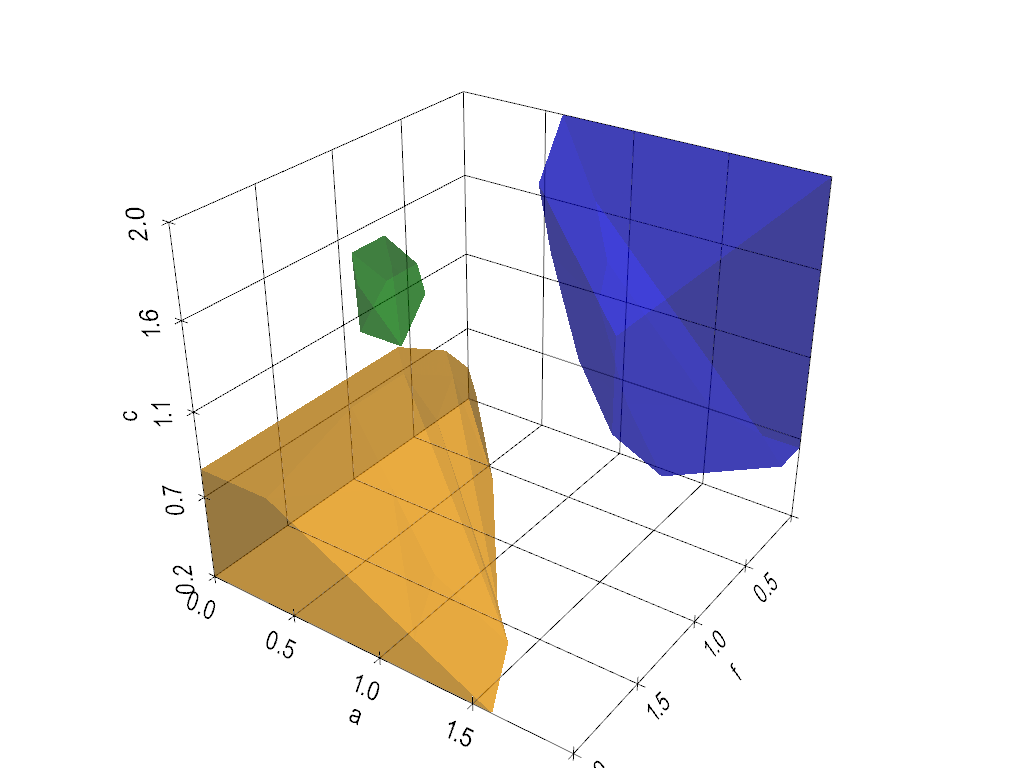

In [36]:
pl = pv.Plotter(notebook=True)

cloud = pv.PolyData(c1_overlaps)
volume = cloud.delaunay_3d(alpha=0)
shell = volume.extract_surface(algorithm=None)
pl.add_mesh(shell, color="#ffa500", opacity=0.5)

cloud = pv.PolyData(c11_overlaps)
volume = cloud.delaunay_3d(alpha=0)
shell = volume.extract_surface(algorithm=None)
pl.add_mesh(shell, color="#0000ff", opacity=0.5)

cloud = pv.PolyData(te_overlaps)
volume = cloud.delaunay_3d(alpha=0)
shell = volume.extract_surface(algorithm=None)
pl.add_mesh(shell, color="green", opacity=0.5)

# Set bounds and grid
pl.show_bounds(location="outer", grid="front")
# Set the camera settings
pl.camera_position = 'yz'
pl.camera.elevation= 30 #30, 20
pl.camera.azimuth = 35 # 52, 25
# Label the axis
labels = dict(xtitle="f", ytitle="a", ztitle="c")
pl.show_grid(**labels, font_size=20, font_family="arial", bold=False)#, n_xlabels=8, n_ylabels=8, n_zlabels=10)

if figure_save_path:
    pl.save_graphic("{}{}_overlap.svg".format(figure_save_path, group))

pl.show()